In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_white"
import plotly.colors as colors
import matplotlib.ticker as mtick
import missingno as msno
import warnings

warnings.filterwarnings('ignore')


# Read data

In [3]:
# 1. Bảng Master (Dữ liệu tham chiếu)
df_products = pd.read_csv("products.csv")
df_customers = pd.read_csv("customers.csv")
df_promotions = pd.read_csv("promotions.csv")
df_geography = pd.read_csv("geography.csv")

# 2. Bảng Transaction (Giao dịch)
df_orders = pd.read_csv("orders.csv")
df_order_items = pd.read_csv("order_items.csv")
df_payments = pd.read_csv("payments.csv")
df_shipments = pd.read_csv("shipments.csv")
df_returns = pd.read_csv("returns.csv")
df_reviews = pd.read_csv("reviews.csv")

# 3. Bảng Analytical (Phân tích)
df_sales = pd.read_csv("sales.csv")
df_sample_submission = pd.read_csv("sample_submission.csv")

# 4. Bảng Operational (Vận hành)
df_inventory = pd.read_csv("inventory.csv")
df_web_traffic = pd.read_csv("web_traffic.csv")

# A. Product - Danh muc va co cau san pham
## 1. So luong san pham va co cau danh muc

In [4]:
df_products.head(5)

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


In [6]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   str    
 2   category      2412 non-null   str    
 3   segment       2412 non-null   str    
 4   size          2412 non-null   str    
 5   color         2412 non-null   str    
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 150.9 KB


In [11]:
df_products.describe()

,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000


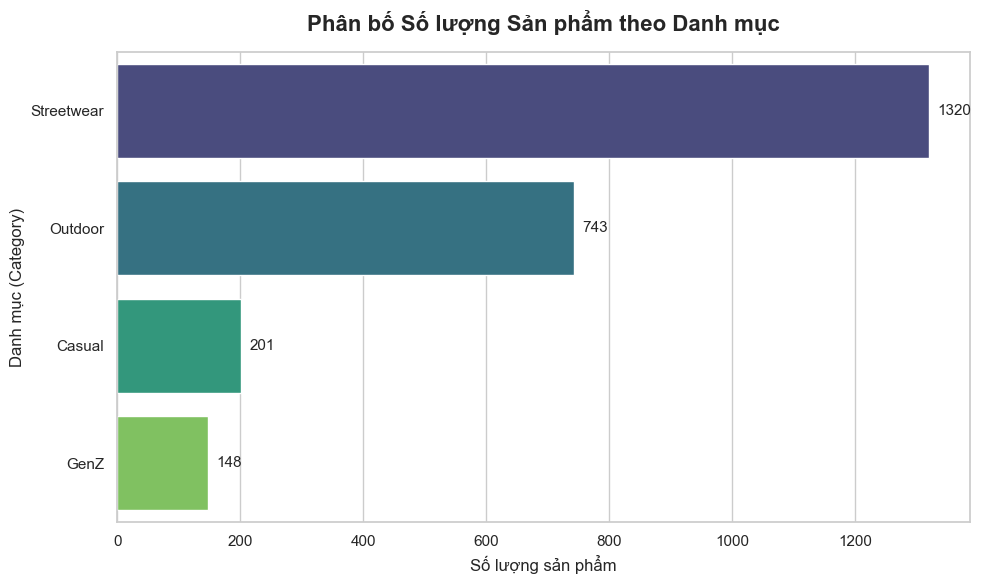

In [ ]:
# So luong san pham theo category
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

category_order = df_products['category'].value_counts().index

ax = sns.countplot(
    data=df_products, 
    y='category', 
    order=category_order, 
    palette='viridis' # Bộ màu dải nhiệt độ nhìn rất "data science"
)

# Thêm tiêu đề và chỉnh font nhãn
plt.title('Phân bố Số lượng Sản phẩm theo Danh mục', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Số lượng sản phẩm', fontsize=12)
plt.ylabel('Danh mục (Category)', fontsize=12)

# Thêm con số chính xác (data labels) ở đuôi mỗi cột
for p in ax.patches:
    width = p.get_width()
    # Chỉ thêm text nếu cột có giá trị (tránh lỗi với cột 0)
    if width > 0:
        plt.text(
            width + max(df_products['category'].value_counts()) * 0.01, # Chỉnh vị trí chữ cách cột một chút
            p.get_y() + p.get_height() / 2, 
            f'{int(width)}', 
            va='center', 
            fontsize=11
        )

# Tối ưu hóa khoảng cách để không bị cắt chữ khi xuất ảnh
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

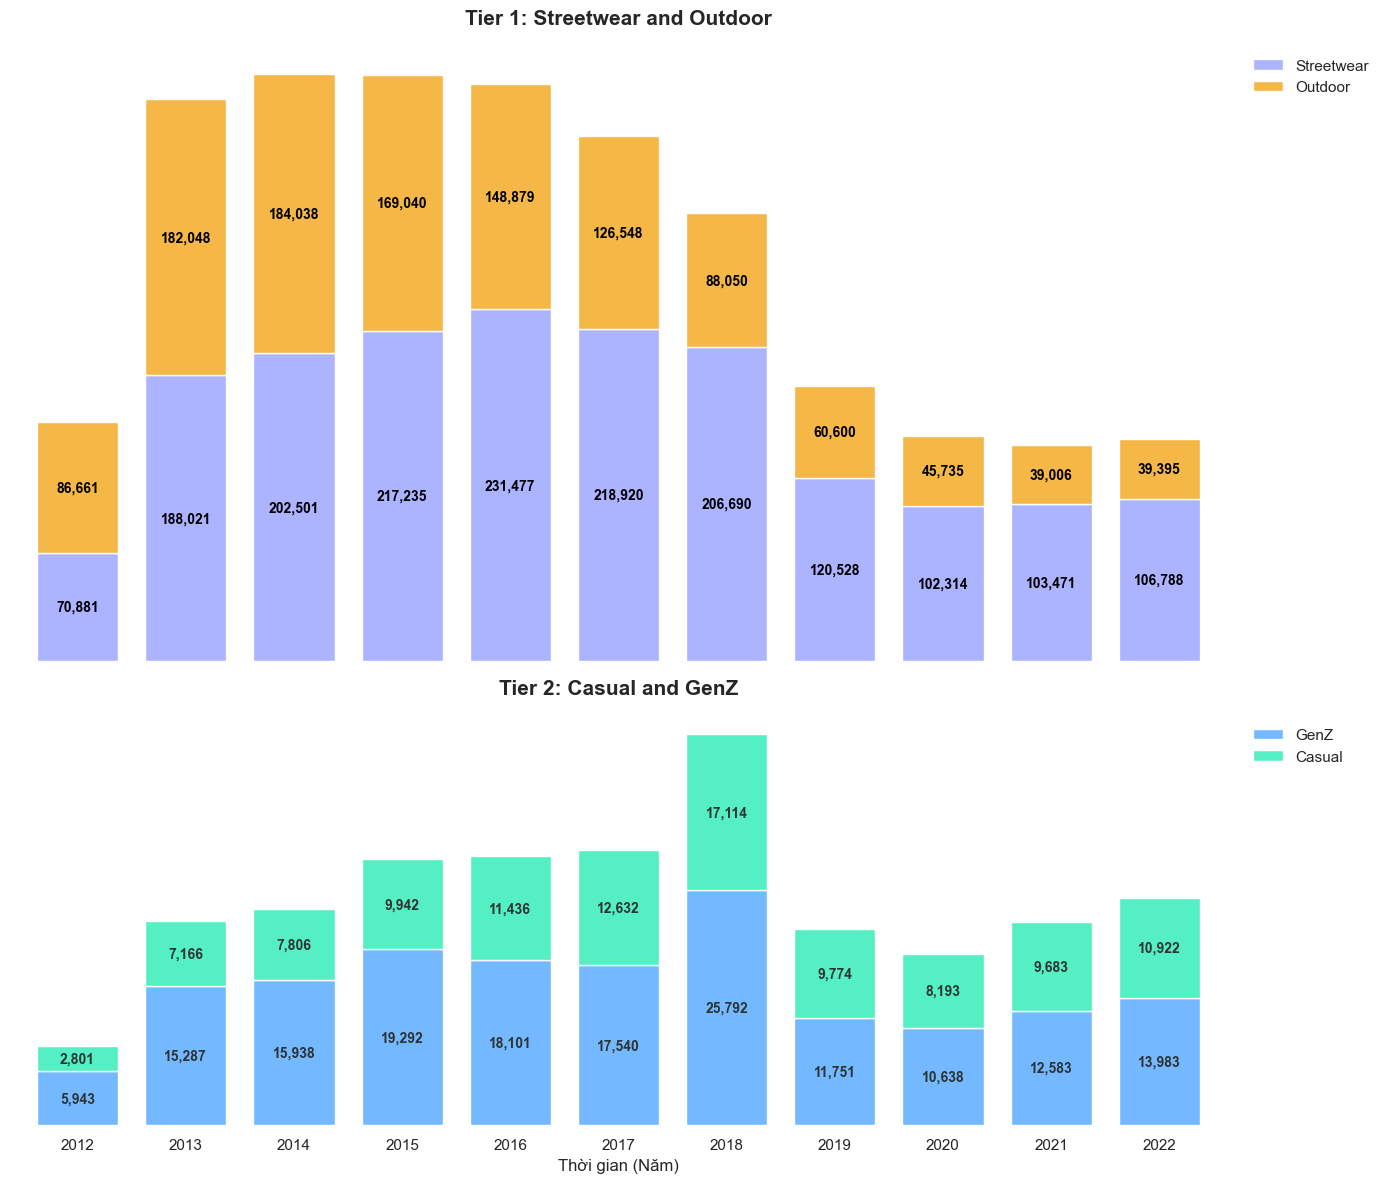

In [58]:
# So luong san pham theo category theo tung nam, bieu do cot dung
# 1. NỐI DỮ LIỆU
# Nối Items với Products để lấy Category
df_merged = pd.merge(df_order_items, df_products[['product_id', 'category']], on='product_id', how='left')
# Nối với Orders để lấy Ngày tháng
df_merged = pd.merge(df_merged, df_orders[['order_id', 'order_date']], on='order_id', how='left')

# 2. TRÍCH XUẤT NĂM VÀ TÍNH TỔNG
df_merged['order_date'] = pd.to_datetime(df_merged['order_date'])
df_merged['year'] = df_merged['order_date'].dt.year

# Gom nhóm theo Năm và Category
category_yearly_qty = df_merged.groupby(['year', 'category'])['quantity'].sum().reset_index()

pivot_df = category_yearly_qty.pivot(index='year', columns='category', values='quantity').fillna(0)

# 1. PHÂN LOẠI NHÓM (TIERS)
tier_1_cols = ['Streetwear', 'Outdoor'] # Các nhóm có sản lượng hàng trăm ngàn
tier_2_cols = ['GenZ', 'Casual']        # Các nhóm có sản lượng hàng chục ngàn

# 2. KHỞI TẠO KHUNG BIỂU ĐỒ (2 Tầng)
# gridspec_kw giúp Tầng 1 cao hơn Tầng 2 một chút (tỷ lệ 1.5 : 1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [1.5, 1]})
sns.set_theme(style="white")

# ---------------- TẦNG 1: NHÓM SẢN LƯỢNG CAO ----------------
pivot_df[tier_1_cols].plot(
    kind='bar', stacked=True, ax=ax1, 
    color=["#ADB4FF", "#F5B847"], # Xám và Vàng
    edgecolor='white', width=0.75
)
ax1.set_title('Tier 1: Streetwear and Outdoor', fontsize=15, fontweight='bold', pad=15)

# Gắn nhãn số lượng cho Tầng 1
for c in ax1.containers:
    labels = [f'{int(v.get_height()):,}' if v.get_height() > 0 else '' for v in c]
    ax1.bar_label(c, labels=labels, label_type='center', color='black', fontweight='bold', fontsize=10)

# ---------------- TẦNG 2: NHÓM SẢN LƯỢNG THẤP ----------------
pivot_df[tier_2_cols].plot(
    kind='bar', stacked=True, ax=ax2, 
    color=['#74B9FF', '#55EFC4'], # Xanh dương và Xanh ngọc
    edgecolor='white', width=0.75
)
ax2.set_title('Tier 2: Casual and GenZ', fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel('Thời gian (Năm)', fontsize=12)

# Gắn nhãn số lượng cho Tầng 2
for c in ax2.containers:
    labels = [f'{int(v.get_height()):,}' if v.get_height() > 0 else '' for v in c]
    ax2.bar_label(c, labels=labels, label_type='center', color='#2D3436', fontweight='bold', fontsize=10)

# 3. TRANG TRÍ CHUNG
# Đẩy chú thích ra ngoài
ax1.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

# Giữ trục X nằm ngang
plt.xticks(rotation=0)

# Ẩn trục Y vì đã dán số trực tiếp để báo cáo nhìn "sạch" hơn
ax1.axes.get_yaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

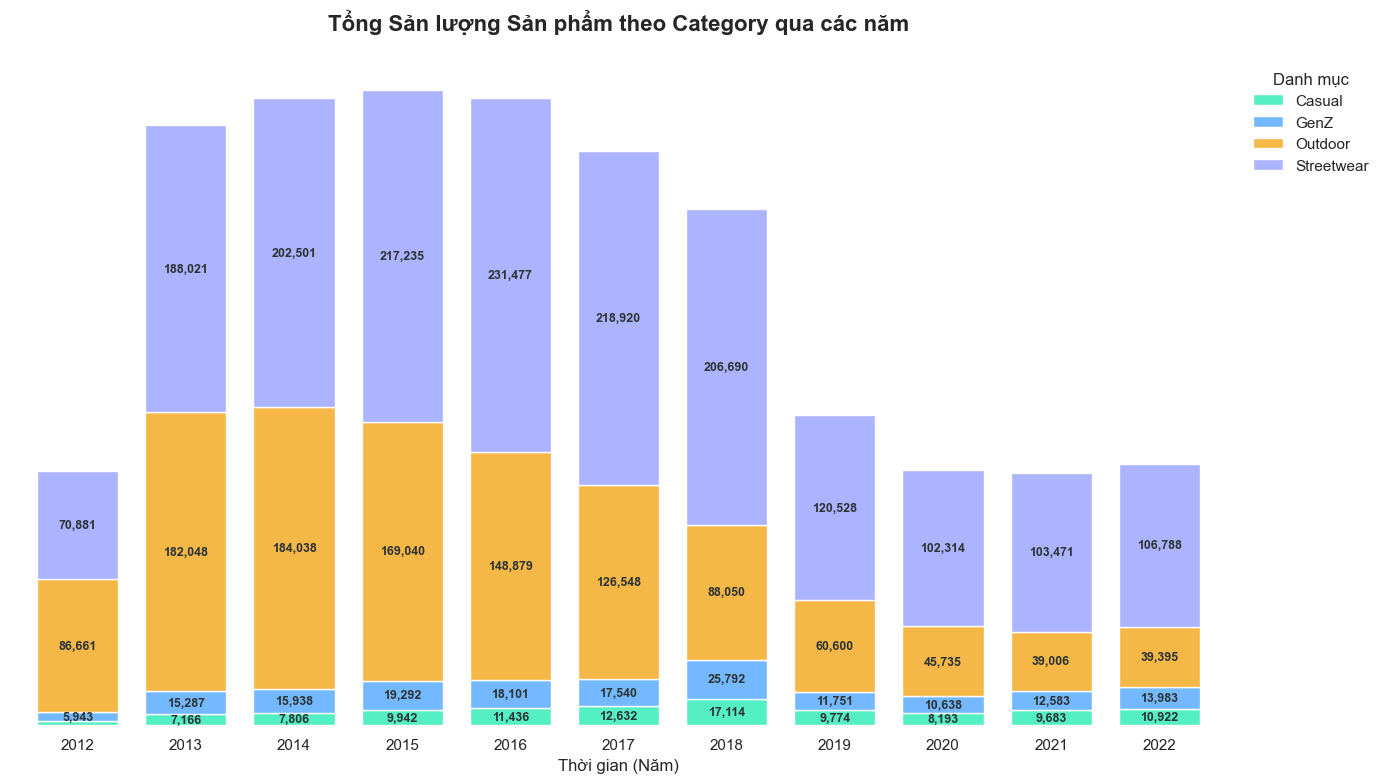

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. NỐI DỮ LIỆU & TRÍCH XUẤT NĂM (Giữ nguyên)
df_merged = pd.merge(df_order_items, df_products[['product_id', 'category']], on='product_id', how='left')
df_merged = pd.merge(df_merged, df_orders[['order_id', 'order_date']], on='order_id', how='left')
df_merged['order_date'] = pd.to_datetime(df_merged['order_date'])
df_merged['year'] = df_merged['order_date'].dt.year

# 2. GOM NHÓM VÀ XOAY DỮ LIỆU (Giữ nguyên)
category_yearly_qty = df_merged.groupby(['year', 'category'])['quantity'].sum().reset_index()
pivot_df = category_yearly_qty.pivot(index='year', columns='category', values='quantity').fillna(0)

# 3. VẼ BIỂU ĐỒ GỘP 4 CATEGORY
sns.set_theme(style="white")

# Dùng chung 1 figure, truyền 4 màu vào tham số color
# Thứ tự màu sẽ tương ứng với thứ tự cột trong pivot_df (thường là A-Z: Casual, GenZ, Outdoor, Streetwear)
ax = pivot_df.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 8), 
    color=["#55EFC4", "#74B9FF", "#F5B847", "#ADB4FF"], # Xanh ngọc, Xanh dương, Vàng, Xám xanh
    edgecolor='white', 
    width=0.75
)

plt.title('Tổng Sản lượng Sản phẩm theo Category qua các năm', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Thời gian (Năm)', fontsize=12)

# 4. GẮN NHÃN SỐ LƯỢNG
for c in ax.containers:
    # Mẹo nhỏ: Vì gộp lại thì khối Casual và GenZ sẽ rất mỏng. 
    # Ta thêm điều kiện v.get_height() > 5000 để ẩn số của những khối quá nhỏ, tránh chữ bị đè ra ngoài.
    labels = [f'{int(v.get_height()):,}' if v.get_height() > 5000 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='#2D3436', fontweight='bold', fontsize=9)

# 5. TRANG TRÍ CHUNG
# Đẩy chú thích ra ngoài
plt.legend(title='Danh mục', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

# Giữ trục X nằm ngang
plt.xticks(rotation=0)

# Ẩn trục Y để báo cáo nhìn "sạch" hơn
ax.axes.get_yaxis().set_visible(False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [59]:
df_order_items.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,714669.0,NaN,NaN,NaN,411615.076561,240480.310686,1.0,203229.0,409306.0,618981.0,834397.0
product_id,714669.0,NaN,NaN,NaN,1234.93137,691.332564,1.0,689.0,990.0,2045.0,2412.0
quantity,714669.0,NaN,NaN,NaN,4.495988,2.290143,1.0,2.0,4.0,6.0,8.0
unit_price,714669.0,NaN,NaN,NaN,5114.690157,3774.817912,392.57,1906.89,4257.77,7273.76,43056.0
discount_amount,714669.0,NaN,NaN,NaN,1048.887415,2280.530606,0.0,0.0,0.0,967.63,35235.47
promo_id,276316,50,PROMO-0014,11451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promo_id_2,206,2,PROMO-0015,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# So  luong san pham theo category va segment
# df_products.groupby(['category', 'segment']).agg(['count'])

df_summary = df_products.groupby(['category', 'segment']).agg(
    so_luong=('price', 'count'),
    gia_trung_binh=('price', 'mean')
).reset_index()

print(df_summary)

     category      segment  so_luong  gia_trung_binh
0      Casual   Activewear        32     4149.536881
1      Casual  All-weather       169     3864.746053
2        GenZ       Trendy       148     2212.785086
3     Outdoor   Activewear       566     2510.382044
4     Outdoor      Premium       177     2387.674872
5  Streetwear     Balanced       306     9230.241172
6  Streetwear     Everyday       405     7549.187730
7  Streetwear  Performance       347     6572.845478
8  Streetwear     Standard       262     2928.592346


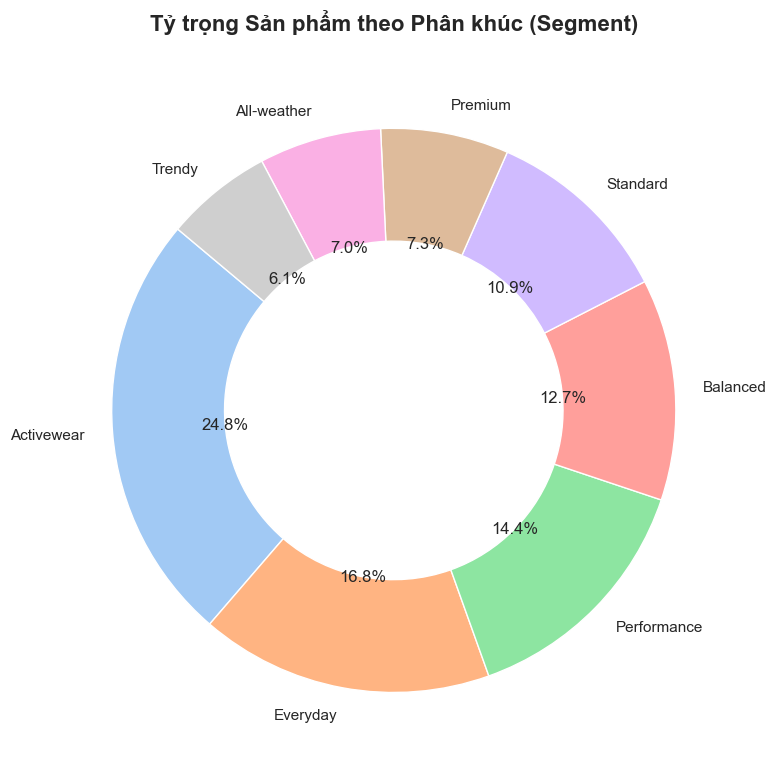

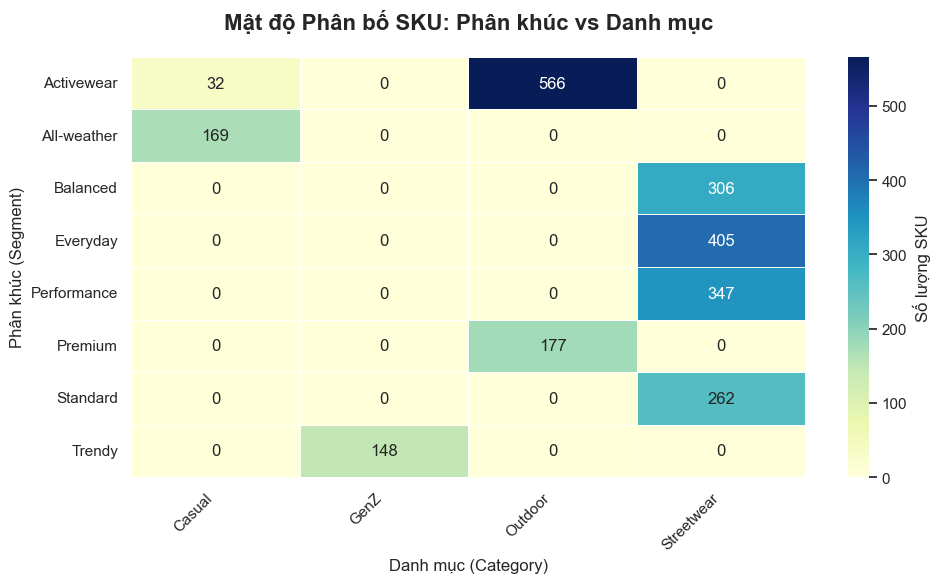

In [ ]:
# Ty tyrong san pham theo phan khuc vs mat do phan bo SKU
plt.figure(figsize=(8, 8))

# Lấy số liệu
segment_counts = df_products['segment'].value_counts()

# Vẽ biểu đồ tròn (Pie chart), thêm thuộc tính wedgeprops để đục lỗ ở giữa tạo thành Donut
plt.pie(
    segment_counts, 
    labels=segment_counts.index, 
    autopct='%1.1f%%', # Hiển thị phần trăm với 1 chữ số thập phân
    startangle=140,    # Xoay góc bắt đầu cho đẹp mắt
    colors=sns.color_palette("pastel"), # Dùng bảng màu pastel nhẹ nhàng
    wedgeprops=dict(width=0.4, edgecolor='white') # Đục lỗ 40% và viền trắng phân cách
)

# Thêm tiêu đề
plt.title('Tỷ trọng Sản phẩm theo Phân khúc (Segment)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 2: HEATMAP - SEGMENT vs CATEGORY
# ==========================================
plt.figure(figsize=(10, 6))

# Tạo bảng tần số (crosstab) đếm số lượng SKU cho từng cặp Segment - Category
heatmap_data = pd.crosstab(df_products['segment'], df_products['category'])

# Vẽ Heatmap
ax = sns.heatmap(
    heatmap_data, 
    annot=True,       # Bật hiển thị con số trên từng ô
    fmt='d',          # Định dạng số nguyên (không có dấu phẩy thập phân)
    cmap='YlGnBu',    # Bảng màu chuyển từ Vàng (thấp) sang Xanh (cao)
    linewidths=0.5,   # Thêm đường viền giữa các ô cho dễ nhìn
    cbar_kws={'label': 'Số lượng SKU'} # Ghi chú cho thang đo bên cạnh
)

# Xoay nhãn trục X để không bị đè chữ nếu tên Category quá dài
plt.xticks(rotation=45, ha='right')

# Thêm tiêu đề và nhãn
plt.title('Mật độ Phân bố SKU: Phân khúc vs Danh mục', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Danh mục (Category)', fontsize=12)
plt.ylabel('Phân khúc (Segment)', fontsize=12)

plt.tight_layout()
plt.show()

## 2. Co cau gia & margin

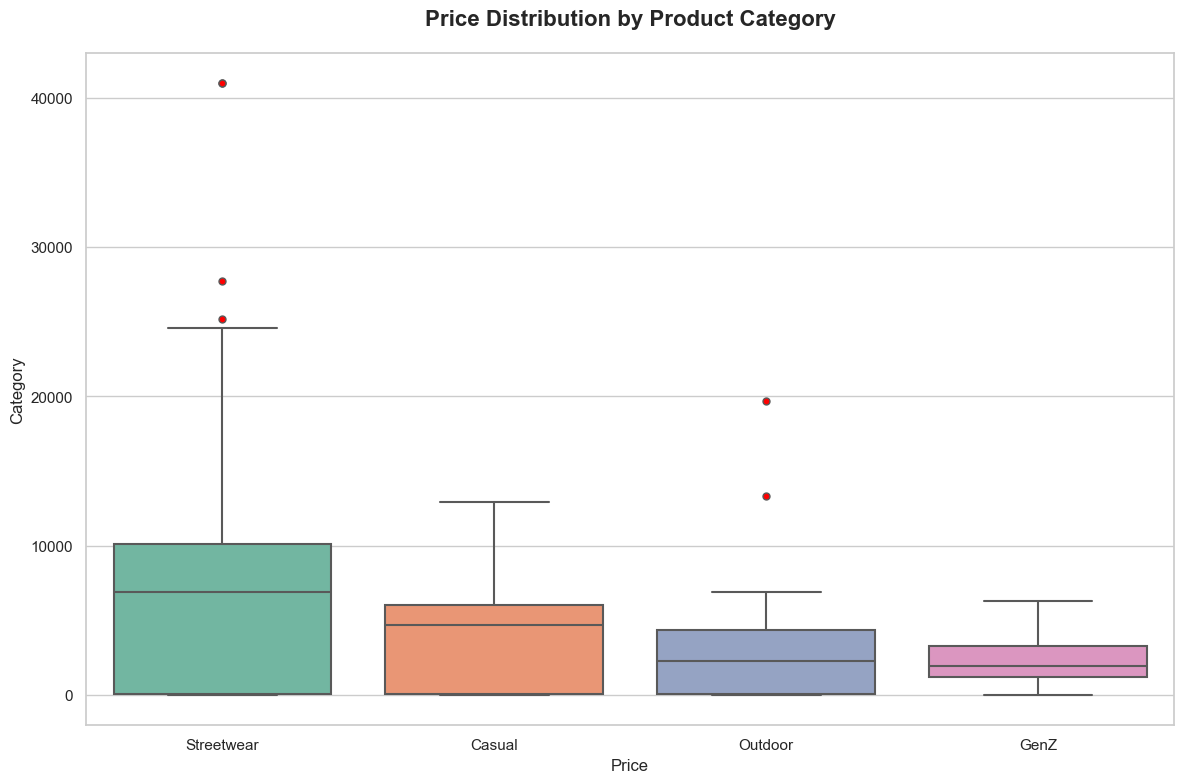

In [27]:
# 2. Configure the plot figure size and style
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 3. Create the horizontal box plot
# x='price' displays the price range (min, max, median, quartiles) on the X-axis
# y='category' groups the data by product category on the Y-axis
sns.boxplot(
    data=df_products, 
    x='category', 
    y='price', 
    palette='Set2', # Use a visually appealing color palette
    linewidth=1.5,
    # Configure outlier properties: circular marker, red fill color, size 5
    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 5} 
)

# 4. Set the title and axis labels
plt.title('Price Distribution by Product Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Category', fontsize=12)

# 5. Optimize the layout to prevent label clipping
plt.tight_layout()

# 6. Display the generated plot
plt.show()

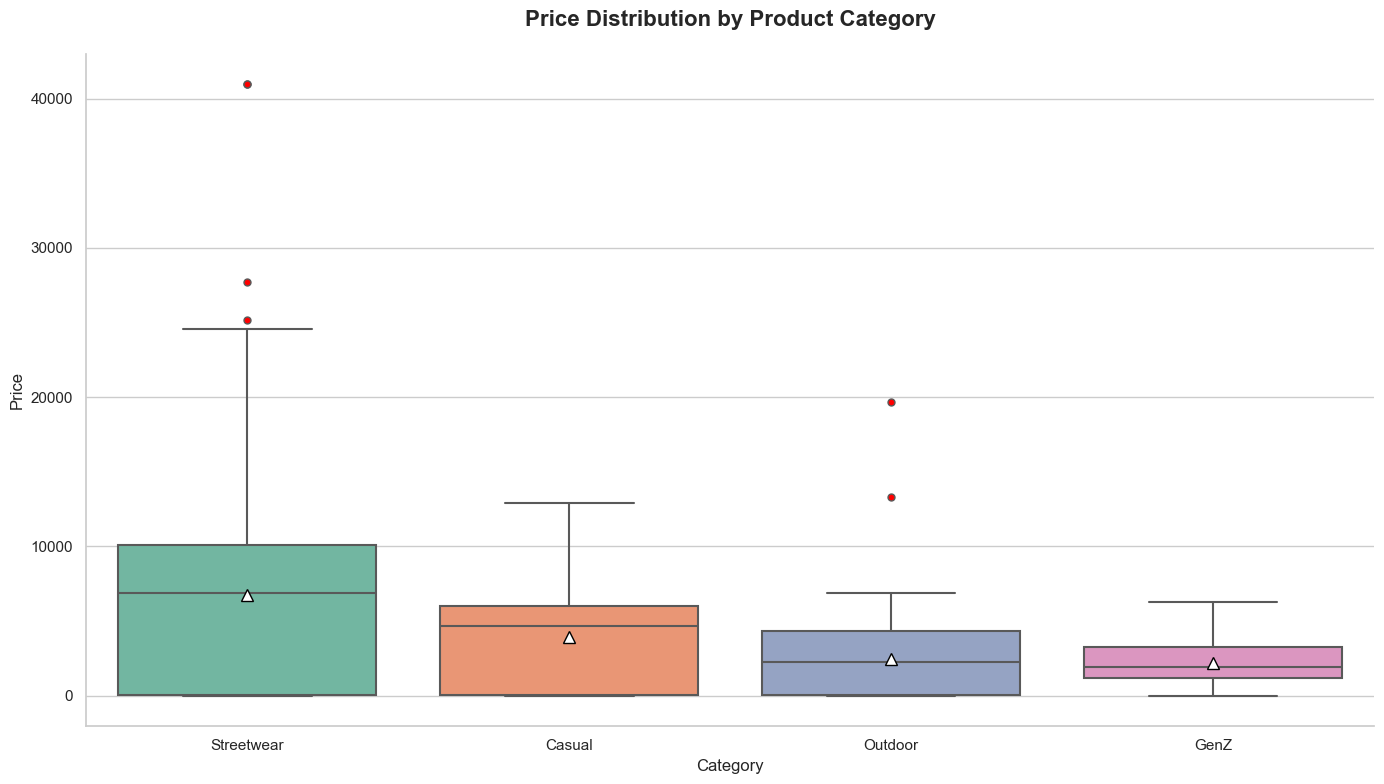

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configure the plot figure size and style
plt.figure(figsize=(14, 8)) # Slightly wider to accommodate text labels
sns.set_theme(style="whitegrid")

# 2. Create the vertical box plot
ax = sns.boxplot(
    data=df_products, 
    x='category', 
    y='price', 
    palette='Set2', 
    linewidth=1.5,
    # SHOW THE MEAN: Display a visual marker for the average
    showmeans=True,
    meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8},
    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 5} 
)

# 3. Add exact numerical labels for Mean, Median, and Max
# Get the order of categories exactly as they appear on the X-axis
categories = [t.get_text() for t in ax.get_xticklabels()]

# Loop through each category to calculate and plot the text
for i, cat in enumerate(categories):
    # Filter data for the current category
    cat_data = df_products[df_products['category'] == cat]['price']
    
    mean_val = cat_data.mean()
    median_val = cat_data.median()
    max_val = cat_data.max()

# 4. Set the title and axis labels
plt.title('Price Distribution by Product Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12) # Fixed to match x='category'
plt.ylabel('Price', fontsize=12)    # Fixed to match y='price'

# Remove top and right spines for a cleaner look
sns.despine()

# 5. Optimize the layout to prevent label clipping
plt.tight_layout()

# 6. Display the generated plot
plt.show()

In [49]:
# 1. Xem thống kê tổng quan để thấy rõ Q1 và Min đang là bao nhiêu
print(df_products.groupby('category')['price'].describe())

# 2. Đếm xem có chính xác bao nhiêu sản phẩm có giá bằng 0
# zero_price_items = df_products[df_products['price'] == 0]
# print(f"Số lượng sản phẩm giá 0 đồng: {len(zero_price_items)}")

# 3. Xem thử đó là những sản phẩm gì để đoán nguyên nhân
# print(zero_price_items.head())

             count         mean          std        min          25%  \
category                                                               
Casual       201.0  3910.085887  3411.745591  14.160292    40.761524   
GenZ         148.0  2212.785086  1572.110738  16.387260  1204.743703   
Outdoor      743.0  2481.150322  2141.029323  11.259873    46.210459   
Streetwear  1320.0  6765.108640  5417.864270   9.056594    77.161363   

                    50%           75%       max  
category                                         
Casual      4647.476842   5983.740000  12927.60  
GenZ        1926.924477   3280.739318   6293.70  
Outdoor     2267.370000   4367.613138  19686.87  
Streetwear  6878.072483  10080.613421  40950.00  


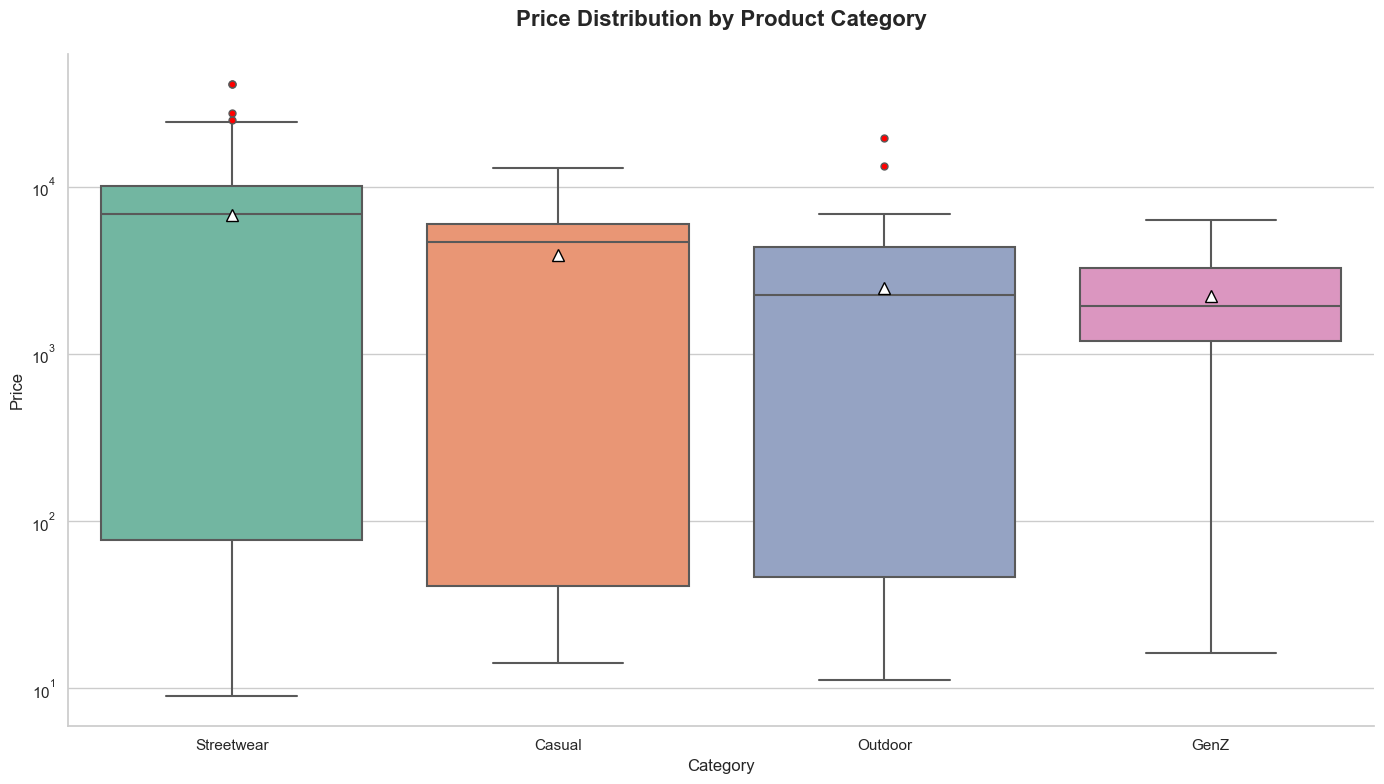

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configure the plot figure size and style
plt.figure(figsize=(14, 8)) # Slightly wider to accommodate text labels
sns.set_theme(style="whitegrid")

# 2. Create the vertical box plot
ax = sns.boxplot(
    data=df_products, 
    x='category', 
    y='price', 
    palette='Set2', 
    linewidth=1.5,
    # SHOW THE MEAN: Display a visual marker for the average
    showmeans=True,
    meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8},
    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 5} 
)
ax.set_yscale('log')
# 3. Add exact numerical labels for Mean, Median, and Max
# Get the order of categories exactly as they appear on the X-axis
categories = [t.get_text() for t in ax.get_xticklabels()]

# Loop through each category to calculate and plot the text
for i, cat in enumerate(categories):
    # Filter data for the current category
    cat_data = df_products[df_products['category'] == cat]['price']
    
    mean_val = cat_data.mean()
    median_val = cat_data.median()
    max_val = cat_data.max()

# 4. Set the title and axis labels
plt.title('Price Distribution by Product Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12) # Fixed to match x='category'
plt.ylabel('Price', fontsize=12)    # Fixed to match y='price'

# Remove top and right spines for a cleaner look
sns.despine()

# 5. Optimize the layout to prevent label clipping
plt.tight_layout()

# 6. Display the generated plot
plt.show()

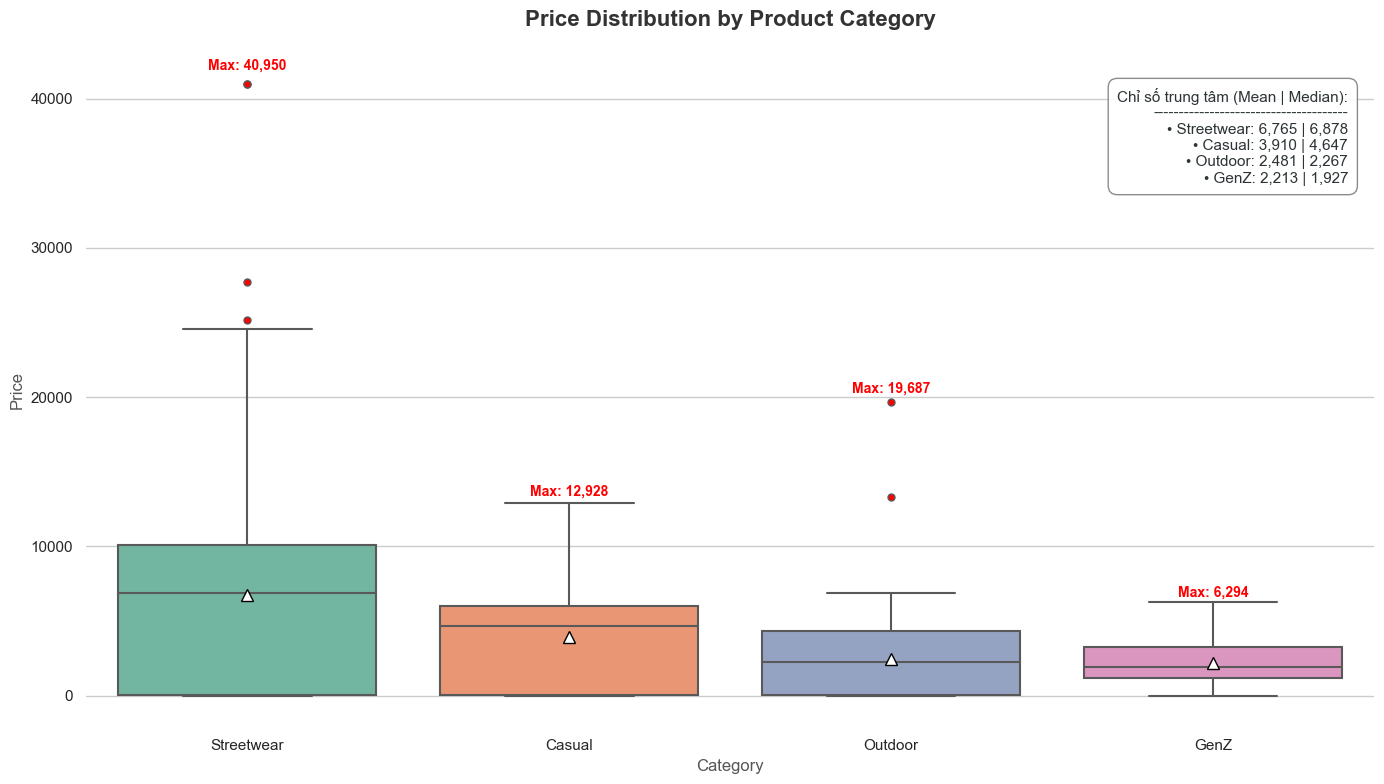

In [ ]:
# Box plot category x price
# 1. CẤU HÌNH BIỂU ĐỒ
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Vẽ Box Plot (Giữ nguyên các thiết lập đánh dấu Mean)
ax = sns.boxplot(
    data=df_products, 
    x='category', 
    y='price', 
    palette='Set2', 
    linewidth=1.5,
    showmeans=True,
    meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8},
    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 5} 
)

# 2. TÍNH TOÁN VÀ XÂY DỰNG NỘI DUNG BẢNG TÓM TẮT
categories = [t.get_text() for t in ax.get_xticklabels()]

# Tiêu đề của bảng tóm tắt
summary_text = "Chỉ số trung tâm (Mean | Median):\n"
summary_text += "-" * 38 + "\n"

for i, cat in enumerate(categories):
    cat_data = df_products[df_products['category'] == cat]['price']
    
    mean_val = cat_data.mean()
    median_val = cat_data.median()
    max_val = cat_data.max()
    
    # Nối thêm số liệu của từng danh mục vào bảng tóm tắt
    summary_text += f"• {cat}: {mean_val:,.0f} | {median_val:,.0f}\n"
    
    # Giữ lại nhãn Max dán trực tiếp lên đỉnh Outlier vì nó mang tính cảnh báo cục bộ
    ax.text(i, max_val + (max_val * 0.02), f'Max: {max_val:,.0f}', 
            ha='center', va='bottom', size=10, color='red', weight='bold')

# 3. ĐẶT BẢNG TÓM TẮT VÀO GÓC TRÊN BÊN PHẢI (TOP RIGHT)
# Cấu hình hộp nền trắng, viền xám, bo góc nhẹ
bbox_props = dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="gray", alpha=0.9)

# Đặt text ở tọa độ X=0.98, Y=0.95 (gần sát góc phải trên cùng của biểu đồ)
ax.text(0.98, 0.95, summary_text.strip(), 
        transform=ax.transAxes, # Dùng hệ tọa độ tương đối (0 đến 1) thay vì tọa độ giá tiền
        fontsize=11, color='#2D3436',
        va='top', ha='right',   # Neo (anchor) góc trên bên phải của hộp chữ vào tọa độ
        bbox=bbox_props)

# 4. TRANG TRÍ CUỐI CÙNG
plt.title('Price Distribution by Product Category', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Category', fontsize=12, color='#555555')
plt.ylabel('Price', fontsize=12, color='#555555')

sns.despine(bottom=True, left=True)
plt.tight_layout()
plt.show()

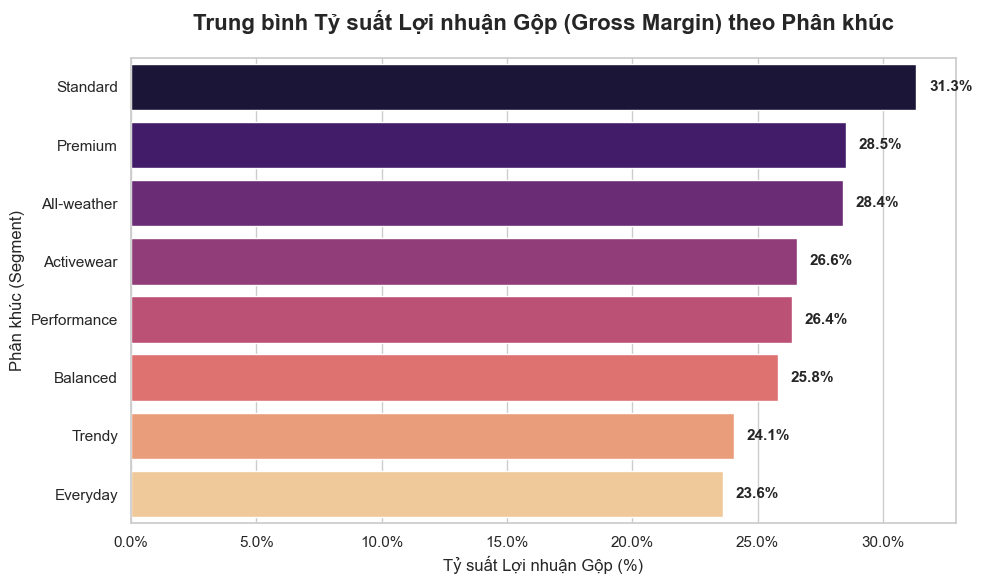

In [ ]:
# 1. TÍNH TOÁN BIÊN LỢI NHUẬN GỘP (GROSS MARGIN)
# Tạo cột mới 'gross_margin' theo công thức đề bài
df_products['gross_margin'] = (df_products['price'] - df_products['cogs']) / df_products['price']

# Gom nhóm theo phân khúc (segment) và tính giá trị trung bình
segment_margin = df_products.groupby('segment')['gross_margin'].mean().reset_index()

# Sắp xếp xếp hạng từ cao xuống thấp
segment_margin = segment_margin.sort_values(by='gross_margin', ascending=False)

# 2. VẼ BIỂU ĐỒ BAR CHART XẾP HẠNG
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ cột ngang
ax = sns.barplot(
    data=segment_margin, 
    x='gross_margin', 
    y='segment', 
    palette='magma' # Bộ màu chuyển sắc nóng, rất phù hợp thể hiện "lợi nhuận"
)

# Thêm tiêu đề và nhãn
plt.title('Trung bình Tỷ suất Lợi nhuận Gộp (Gross Margin) theo Phân khúc', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tỷ suất Lợi nhuận Gộp (%)', fontsize=12)
plt.ylabel('Phân khúc (Segment)', fontsize=12)

# Định dạng trục X hiển thị theo kiểu phần trăm (%)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0)) 

# Thêm con số chính xác (% margin) ở đuôi mỗi cột
for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.005, # Khoảng cách dời chữ ra xa một chút
        p.get_y() + p.get_height() / 2, 
        f'{width:.1%}', # Định dạng hiển thị phần trăm với 1 chữ số thập phân
        va='center', 
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [15]:
# 1. Tính Gross Margin (đề phòng trường hợp bạn chạy ở một file notebook mới)
if 'gross_margin' not in df_products.columns:
    df_products['gross_margin'] = (df_products['price'] - df_products['cogs']) / df_products['price']

# 2. Tìm Segment có Margin trung bình cao nhất
segment_margin = df_products.groupby('segment')['gross_margin'].mean()
highest_margin_segment = segment_margin.idxmax()
highest_margin_value = segment_margin.max()

# 3. Tính tỷ lệ % sản phẩm có margin > 50%
# Lọc ra các sản phẩm có gross_margin lớn hơn 0.5
high_margin_products = df_products[df_products['gross_margin'] > 0.5]

# Tính phần trăm
percentage_high_margin = (len(high_margin_products) / len(df_products)) * 100

# 4. IN KẾT QUẢ RA MÀN HÌNH
print("--- KẾT QUẢ PHÂN TÍCH TỶ SUẤT LỢI NHUẬN ---")
print(f"1. Phân khúc có Margin trung bình cao nhất: {highest_margin_segment} ({highest_margin_value:.1%})")
print(f"2. Tỷ lệ sản phẩm đạt Margin > 50%: {percentage_high_margin:.1f}%")
print(f"   (Cụ thể: {len(high_margin_products)} trên tổng số {len(df_products)} sản phẩm)")

--- KẾT QUẢ PHÂN TÍCH TỶ SUẤT LỢI NHUẬN ---
1. Phân khúc có Margin trung bình cao nhất: Standard (31.3%)
2. Tỷ lệ sản phẩm đạt Margin > 50%: 0.0%
   (Cụ thể: 0 trên tổng số 2412 sản phẩm)


# B. Customer - Ho so & hanh vi khach hang
## 1. Co cau khach hang

In [19]:
df_customers.head(5)

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


In [20]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   customer_id          121930 non-null  int64
 1   zip                  121930 non-null  int64
 2   city                 121930 non-null  str  
 3   signup_date          121930 non-null  str  
 4   gender               121930 non-null  str  
 5   age_group            121930 non-null  str  
 6   acquisition_channel  121930 non-null  str  
dtypes: int64(2), str(5)
memory usage: 6.5 MB


In [22]:
df_customers.describe()

,customer_id,zip
count,121930.000000,121930.000000
mean,78736.898663,50990.165595
std,45492.202886,26871.914605
min,1.000000,1001.000000
25%,39343.500000,28689.250000
50%,78784.500000,49835.000000
75%,118156.750000,73488.000000
max,157563.000000,99950.000000


In [24]:
df_orders.head(5)

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [25]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   order_id        646945 non-null  int64
 1   order_date      646945 non-null  str  
 2   customer_id     646945 non-null  int64
 3   zip             646945 non-null  int64
 4   order_status    646945 non-null  str  
 5   payment_method  646945 non-null  str  
 6   device_type     646945 non-null  str  
 7   order_source    646945 non-null  str  
dtypes: int64(3), str(5)
memory usage: 39.5 MB


In [26]:
df_orders.describe()

,order_id,customer_id,zip
count,646945.000000,646945.000000,646945.000000
mean,417189.470332,84906.203535,55410.740423
std,240785.704463,48446.922752,28876.471824
min,1.000000,1.000000,1001.000000
25%,208728.000000,41336.000000,30904.000000
50%,417211.000000,87279.000000,54129.000000
75%,625628.000000,133282.000000,83301.000000
max,834397.000000,157563.000000,99950.000000


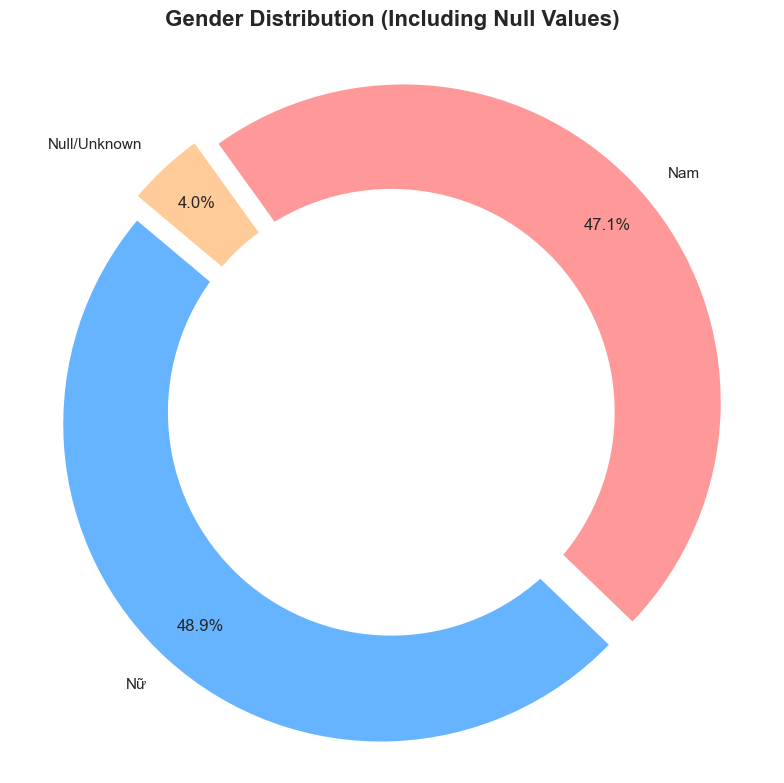

In [ ]:
# Ty le gioi tinh: nam/nu/unknown - donut chart
# df_customers = pd.read_csv("customers.csv")

# 2. Prepare the data
# Calculate counts including NaN values
gender_counts = df_customers['gender'].value_counts(dropna=False)

# Map data labels for visualization (Optional: Translate to Vietnamese as per your prompt)
# 'Male' -> 'Nam', 'Female' -> 'Nữ', NaN -> 'Missing/Null'
label_mapping = {
    'Male': 'Nam',
    'Female': 'Nữ'
}
labels = [label_mapping.get(str(label), 'Null/Unknown') for label in gender_counts.index]
sizes = gender_counts.values

# 3. Create the Donut Chart
plt.figure(figsize=(8, 8))
sns.set_theme(style="white")

# Define professional colors
colors = ['#66b3ff', '#ff9999', '#ffcc99'] # Blue for Male, Pink for Female, Orange for Null

# Plotting the pie chart
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors[:len(labels)],
    pctdistance=0.85, # Position of the percentage text
    explode=[0.05] * len(labels) # Slightly separate slices for better visibility
)

# Draw a white circle in the middle to create the "Donut" effect
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# 4. Final touches
plt.title('Gender Distribution (Including Null Values)', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()

# 5. Display the plot
plt.show()

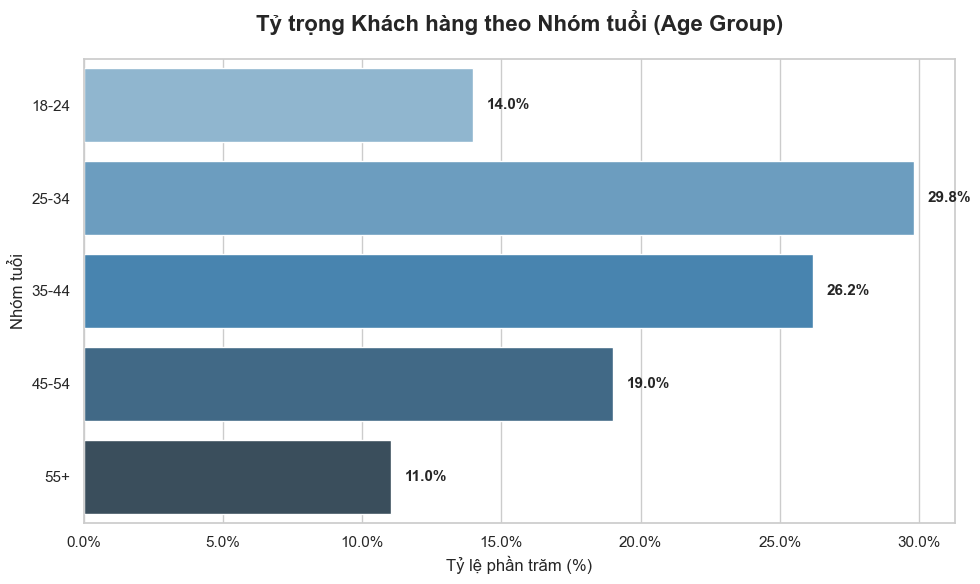

In [ ]:
# Phan bo age_group: <25, 25–34, 35–44, 45–54, 55+ — bar chart ngang
# df_customers = pd.read_csv("customers.csv")

# 1. TÍNH TOÁN TỶ LỆ PHẦN TRĂM
# value_counts(normalize=True) sẽ trả về tỷ lệ (từ 0 đến 1), ta nhân với 100 để ra phần trăm (%)
age_pct = df_customers['age_group'].value_counts(normalize=True).reset_index()
age_pct.columns = ['age_group', 'percentage']
age_pct['percentage'] = age_pct['percentage'] * 100

# Xác định thứ tự hiển thị từ trẻ đến già
age_order = ['<25', '18-24', '25-34', '35-44', '45-54', '55+']
existing_ages = [age for age in age_order if age in age_pct['age_group'].values]

# 2. VẼ BIỂU ĐỒ BAR CHART NGANG THEO PHẦN TRĂM
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Dùng sns.barplot thay vì countplot
ax = sns.barplot(
    data=age_pct, 
    y='age_group', 
    x='percentage', 
    order=existing_ages, 
    palette='Blues_d'
)

# 3. TRANG TRÍ VÀ HIỂN THỊ CON SỐ
plt.title('Tỷ trọng Khách hàng theo Nhóm tuổi (Age Group)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tỷ lệ phần trăm (%)', fontsize=12)
plt.ylabel('Nhóm tuổi', fontsize=12)

# Định dạng trục X hiển thị ký hiệu %
ax.xaxis.set_major_formatter(mtick.PercentFormatter(100)) 

# Gắn data labels (% chính xác) vào đuôi mỗi cột
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        plt.text(
            width + 0.5, # Đẩy chữ ra xa mép cột một chút (0.5%)
            p.get_y() + p.get_height() / 2, 
            f'{width:.1f}%', # Định dạng hiển thị phần trăm với 1 chữ số thập phân
            va='center', 
            fontsize=11,
            fontweight='bold'
        )

# Tối ưu hóa khoảng cách
plt.tight_layout()

# Hiển thị
plt.show()

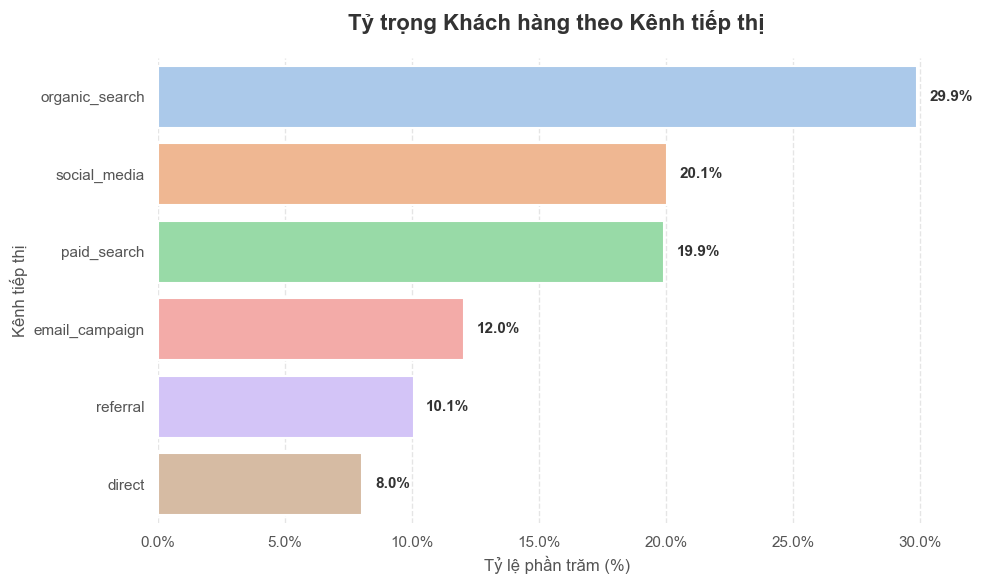

In [31]:
# Kenh tiep thi (acquisition channel): bar chart + ty le %.
# Đảm bảo dữ liệu đã được nạp
# df_customers = pd.read_csv("customers.csv")

# 1. TÍNH TOÁN TỶ LỆ PHẦN TRĂM
channel_pct = df_customers['acquisition_channel'].value_counts(normalize=True).reset_index()
channel_pct.columns = ['acquisition_channel', 'percentage']
channel_pct['percentage'] = channel_pct['percentage'] * 100

# 2. THIẾT LẬP GIAO DIỆN "REPORT-READY"
plt.figure(figsize=(10, 6))
# Dùng nền trắng tinh giản thay vì lưới mặc định
sns.set_theme(style="white") 

# Sử dụng bộ màu pastel thanh lịch, dễ nhìn và phân biệt rõ
pastel_colors = sns.color_palette("pastel")

# Vẽ biểu đồ
ax = sns.barplot(
    data=channel_pct, 
    y='acquisition_channel', 
    x='percentage', 
    palette=pastel_colors,
    edgecolor='white', # Thêm viền trắng mỏng quanh cột cho nét
    linewidth=1.5
)

# 3. TRANG TRÍ CHI TIẾT
plt.title('Tỷ trọng Khách hàng theo Kênh tiếp thị', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Tỷ lệ phần trăm (%)', fontsize=12, color='#555555')
plt.ylabel('Kênh tiếp thị', fontsize=12, color='#555555')

# Định dạng trục X hiển thị ký hiệu %
ax.xaxis.set_major_formatter(mtick.PercentFormatter(100)) 

# Làm mờ trục X và trục Y để chữ không bị gắt
ax.tick_params(colors='#555555', labelsize=11)

# Gắn data labels (% chính xác) vào đuôi mỗi cột
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        plt.text(
            width + 0.5, # Đẩy chữ ra xa mép cột 0.5%
            p.get_y() + p.get_height() / 2, 
            f'{width:.1f}%', 
            va='center', 
            fontsize=11,
            fontweight='bold',
            color='#333333' # Dùng màu xám đậm (dark gray) thay vì đen thui (black) cho sang trọng
        )

# 4. TINH CHỈNH CUỐI CÙNG CHO BÁO CÁO
# Xóa viền (khung) ở trên, phải và dưới để biểu đồ trông thanh thoát
sns.despine(left=True, bottom=True)

# Chỉ bật lưới dọc (trục X) dạng nét đứt, mờ 50% để gióng số liệu dễ hơn
ax.xaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# (Tùy chọn) Lưu ảnh ra file PDF sắc nét để chèn vào báo cáo LaTeX
# plt.savefig('acquisition_channel_distribution.pdf', format='pdf', bbox_inches='tight')

# Hiển thị biểu đồ
plt.show()

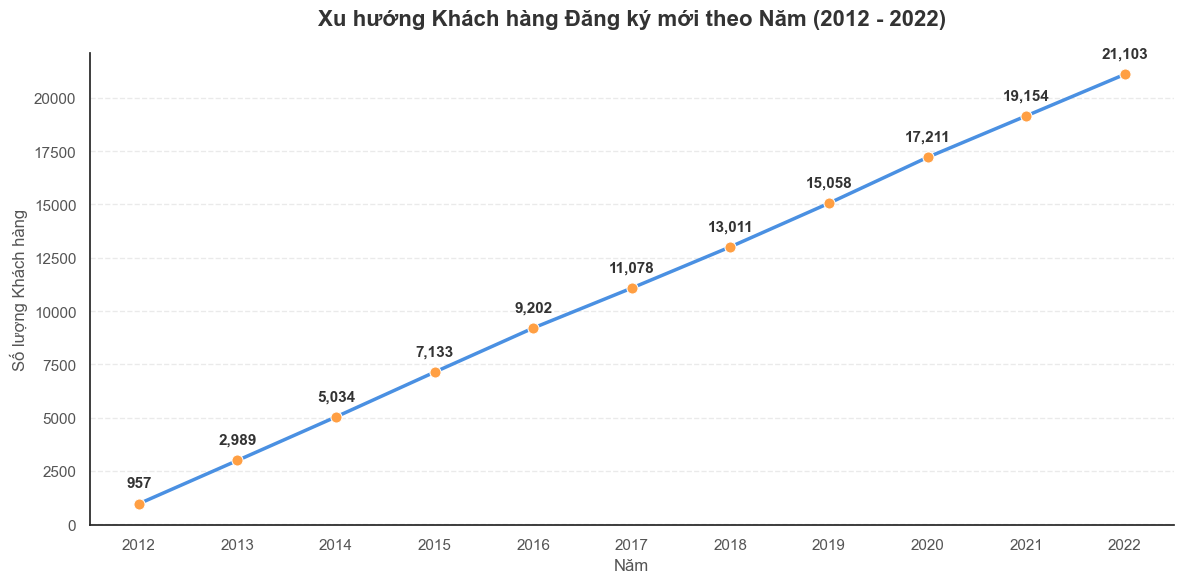

In [32]:
# Xu huong dang ky moi theo nam (signup_date) - line chart
# Đảm bảo dữ liệu đã được nạp
# df_customers = pd.read_csv("customers.csv")

# 1. TIỀN XỬ LÝ DỮ LIỆU THỜI GIAN
# Ép kiểu cột signup_date từ chuỗi (string) sang định dạng thời gian (datetime) của Pandas
df_customers['signup_date'] = pd.to_datetime(df_customers['signup_date'])

# Rút trích Năm (Year) từ ngày đăng ký
df_customers['signup_year'] = df_customers['signup_date'].dt.year

# Gom nhóm đếm số lượng khách đăng ký theo từng năm và sắp xếp thứ tự năm tăng dần
yearly_signups = df_customers['signup_year'].value_counts().sort_index().reset_index()
yearly_signups.columns = ['signup_year', 'customer_count']

# 2. THIẾT LẬP GIAO DIỆN BÁO CÁO
plt.figure(figsize=(12, 6))
sns.set_theme(style="white")

# Vẽ biểu đồ Line Chart
ax = sns.lineplot(
    data=yearly_signups,
    x='signup_year',
    y='customer_count',
    color='#4A90E2',      # Xanh dương đậm chuyên nghiệp
    linewidth=2.5,        # Độ dày của đường line
    marker='o',           # Thêm dấu chấm tròn tại mỗi năm
    markersize=8,
    markerfacecolor='#FF9F43' # Nổi bật dấu chấm bằng màu cam pastel
)

# 3. TRANG TRÍ CHI TIẾT
plt.title('Xu hướng Khách hàng Đăng ký mới theo Năm (2012 - 2022)', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Năm', fontsize=12, color='#555555')
plt.ylabel('Số lượng Khách hàng', fontsize=12, color='#555555')

# Ép trục X chỉ hiển thị số nguyên (các năm), tránh hiển thị số thập phân như 2012.5
plt.xticks(yearly_signups['signup_year'], color='#555555')
plt.yticks(color='#555555')

# Gắn data labels (số lượng cụ thể) lên trên từng điểm mốc
for x, y in zip(yearly_signups['signup_year'], yearly_signups['customer_count']):
    plt.text(
        x, 
        y + (yearly_signups['customer_count'].max() * 0.03), # Đẩy chữ lên trên cao một chút so với dấu chấm
        f'{int(y):,}', # Định dạng có dấu phẩy hàng nghìn (VD: 12,345)
        ha='center',   # Căn giữa chữ so với điểm chấm
        va='bottom', 
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )

# 4. TINH CHỈNH CUỐI CÙNG 
sns.despine() # Bỏ viền trên và phải
ax.grid(axis='y', linestyle='--', alpha=0.4) # Chỉ giữ lại lưới ngang mờ để dễ dóng số liệu

plt.tight_layout()

# Tùy chọn lưu ảnh cho báo cáo
# plt.savefig('yearly_signups_trend.pdf', format='pdf', bbox_inches='tight')

# Hiển thị biểu đồ
plt.show()

# II. Metrics in retail industry
## 1. Sales Performance
### Data profilling

In [34]:
df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3833 non-null   str    
 1   Revenue  3833 non-null   float64
 2   COGS     3833 non-null   float64
dtypes: float64(2), str(1)
memory usage: 90.0 KB


In [36]:
df_sales.describe()

,Revenue,COGS
count,3.833000e+03,3.833000e+03
mean,4.286584e+06,3.695134e+06
std,2.624840e+06,2.219789e+06
min,2.798139e+05,2.365763e+05
25%,2.471089e+06,2.150580e+06
50%,3.647304e+06,3.161113e+06
75%,5.350877e+06,4.637294e+06
max,2.090527e+07,1.653586e+07


In [38]:
df_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        646945 non-null  int64  
 1   payment_method  646945 non-null  str    
 2   payment_value   646945 non-null  float64
 3   installments    646945 non-null  int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 19.7 MB


In [39]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  int64  
 1   product_id       714669 non-null  int64  
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         276316 non-null  str    
 6   promo_id_2       206 non-null     str    
dtypes: float64(2), int64(3), str(2)
memory usage: 38.2 MB


In [40]:
df_web_traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      3652 non-null   str    
 1   sessions                  3652 non-null   int64  
 2   unique_visitors           3652 non-null   int64  
 3   page_views                3652 non-null   int64  
 4   bounce_rate               3652 non-null   float64
 5   avg_session_duration_sec  3652 non-null   float64
 6   traffic_source            3652 non-null   str    
dtypes: float64(2), int64(3), str(2)
memory usage: 199.8 KB


In [42]:
df_promotions.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   promo_id             50 non-null     str    
 1   promo_name           50 non-null     str    
 2   promo_type           50 non-null     str    
 3   discount_value       50 non-null     float64
 4   start_date           50 non-null     str    
 5   end_date             50 non-null     str    
 6   applicable_category  10 non-null     str    
 7   promo_channel        50 non-null     str    
 8   stackable_flag       50 non-null     int64  
 9   min_order_value      50 non-null     int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 4.0 KB


In [9]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])

### Total revenue by date, month, quarter

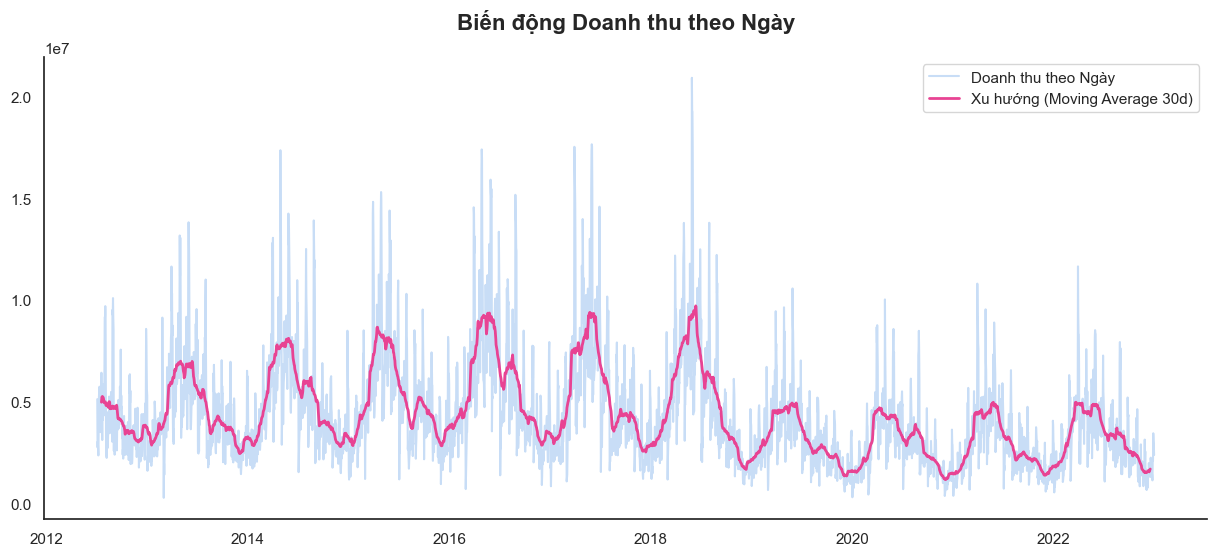

In [11]:
# Phan tich doanh thu theo ngay
df_time = df_sales.set_index('Date').sort_index()
# Gom nhóm theo ngày (D)
daily_rev = df_time['Revenue'].resample('D').sum().reset_index()

plt.figure(figsize=(15, 6))
sns.set_theme(style="white")

# Vẽ dữ liệu thô (màu nhạt hơn để không bị rối)
plt.plot(daily_rev['Date'], daily_rev['Revenue'], color='#4A90E2', alpha=0.3, label='Doanh thu theo Ngày')

# Vẽ đường xu hướng (Trung bình trượt 30 ngày)
daily_rev['Trend'] = daily_rev['Revenue'].rolling(window=30, center=True).mean()
plt.plot(daily_rev['Date'], daily_rev['Trend'], color='#E84393', linewidth=2, label='Xu hướng (Moving Average 30d)')

plt.title('Biến động Doanh thu theo Ngày', fontsize=16, fontweight='bold', pad=20)
plt.legend()
sns.despine()
plt.show()

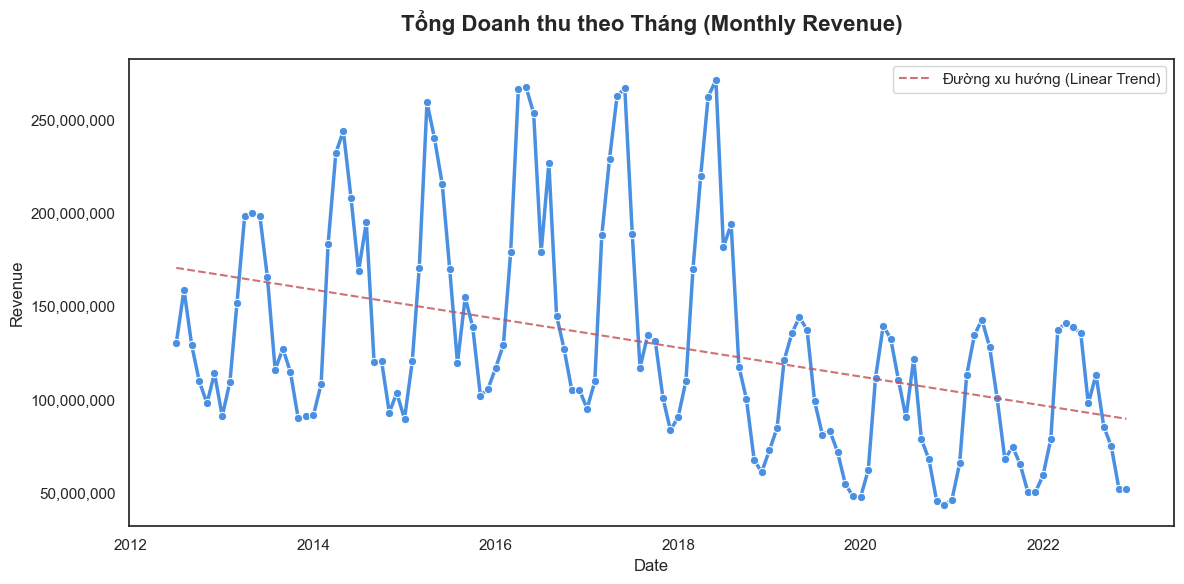

In [12]:
# Gom nhóm theo tháng (MS - Month Start)
monthly_rev = df_time['Revenue'].resample('MS').sum().reset_index()

plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=monthly_rev, x='Date', y='Revenue', marker='o', color='#4A90E2', linewidth=2.5)

# Vẽ Trendline bằng hồi quy tuyến tính
x_numeric = np.arange(len(monthly_rev)) 
z = np.polyfit(x_numeric, monthly_rev['Revenue'], 1)
p = np.poly1d(z)
plt.plot(monthly_rev['Date'], p(x_numeric), "r--", alpha=0.8, label="Đường xu hướng (Linear Trend)")

plt.title('Tổng Doanh thu theo Tháng (Monthly Revenue)', fontsize=16, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.show()

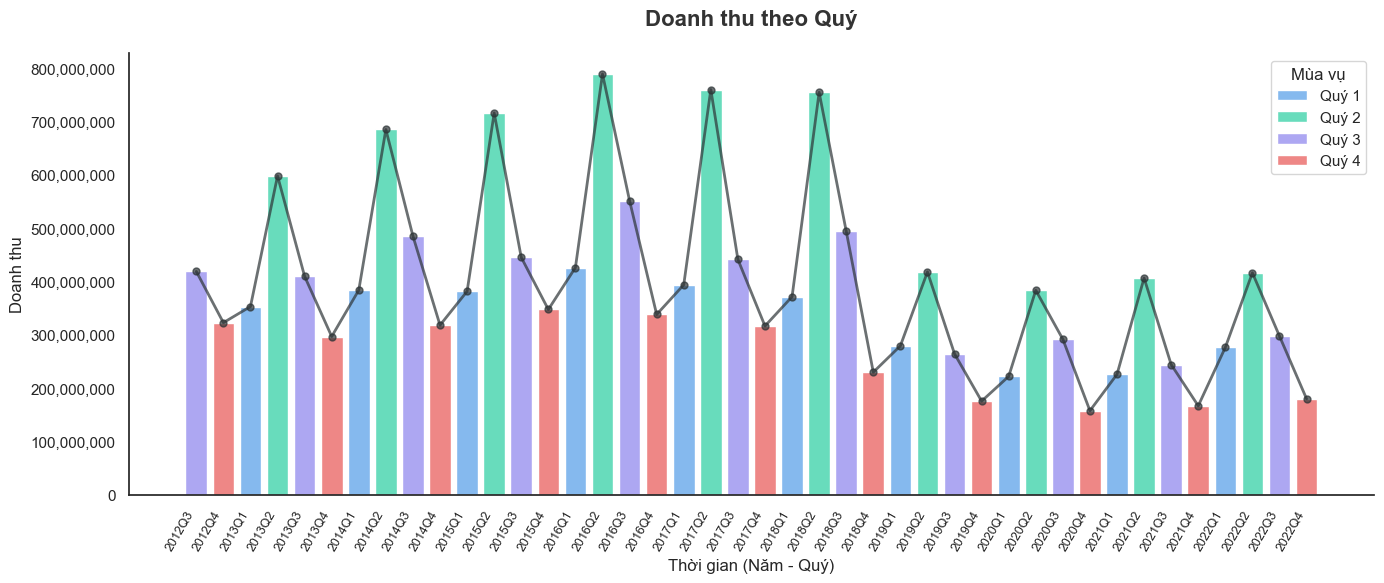

In [15]:
# Giả định df_time đã được tạo từ trước (index là Date)
# df_time = df_sales.set_index('Date').sort_index()

# 1. Gom nhóm theo quý (QS)
quarterly_rev = df_time['Revenue'].resample('QS').sum().reset_index()

# 2. Trích xuất Năm_Quý (để làm nhãn trục X) và số Quý (để tô màu)
quarterly_rev['Year_Quarter'] = quarterly_rev['Date'].dt.to_period('Q').astype(str)
quarterly_rev['Quarter'] = quarterly_rev['Date'].dt.quarter # Kết quả: 1, 2, 3, 4

# 3. VẼ BIỂU ĐỒ
plt.figure(figsize=(14, 6))
sns.set_theme(style="white")

# Định nghĩa bộ màu cho 4 quý (Bạn có thể đổi mã màu HEX theo ý thích)
# Q1: Xanh nhạt, Q2: Xanh ngọc, Q3: Tím nhạt, Q4: Đỏ cam (Làm nổi bật mùa mua sắm cuối năm)
quarter_palette = {1: '#74B9FF', 2: '#55EFC4', 3: '#A29BFE', 4: '#FF7675'}

# Dùng tham số hue='Quarter' và dodge=False để giữ các cột nằm trên 1 hàng
ax = sns.barplot(
    data=quarterly_rev, 
    x='Year_Quarter', 
    y='Revenue', 
    hue='Quarter',
    palette=quarter_palette,
    dodge=False,
    edgecolor='white'
)

# Thêm đường nối (Line) đè lên để thấy rõ xu hướng tổng thể
plt.plot(range(len(quarterly_rev)), quarterly_rev['Revenue'], 
         color='#2D3436', linewidth=2, marker='o', markersize=5, alpha=0.7)

# 4. TRANG TRÍ CHUẨN BÁO CÁO
plt.title('Doanh thu theo Quý', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Thời gian (Năm - Quý)', fontsize=12)
plt.ylabel('Doanh thu', fontsize=12)

# Xoay nhãn trục X cho đỡ bị chen chúc (nếu dữ liệu 10 năm thì bước này rất quan trọng)
plt.xticks(rotation=60, ha='right', fontsize=9) 
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Chỉnh sửa lại bảng chú giải (Legend) cho đẹp
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ['Quý 1', 'Quý 2', 'Quý 3', 'Quý 4'], title='Mùa vụ', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

### AOV (Average order value) by month

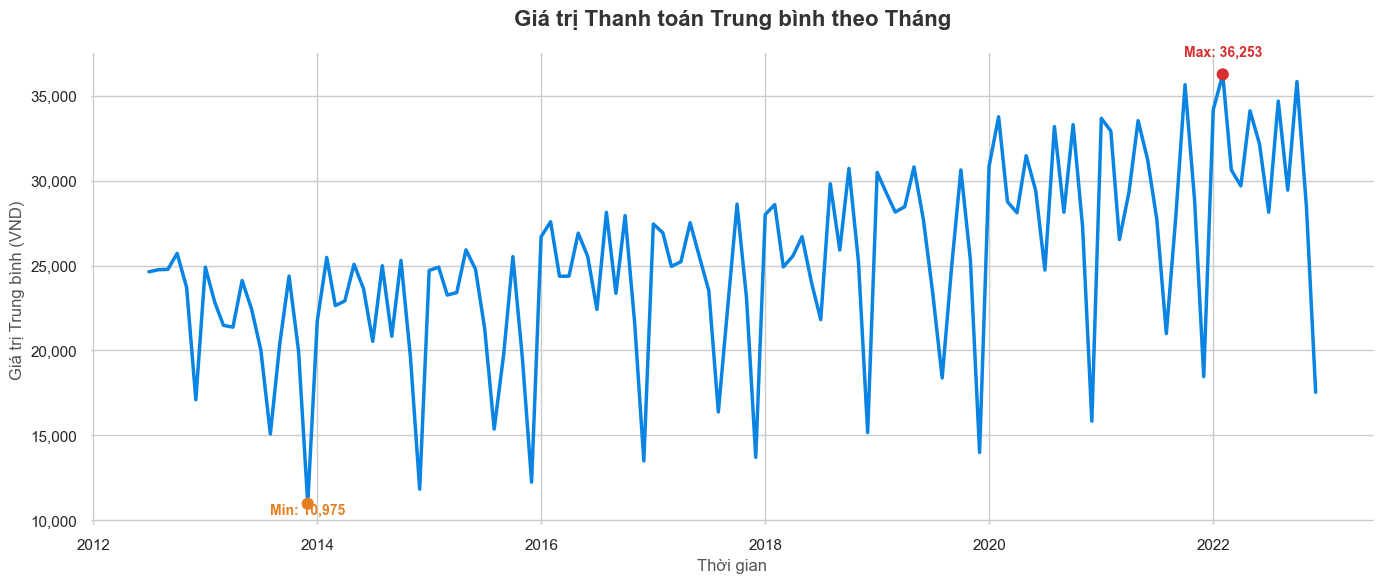

In [62]:
# 1. NỐI DỮ LIỆU TỪ 2 BẢNG
# (Giả định df_payments và df_orders đã được đọc vào Pandas)
df_merged = pd.merge(df_payments, df_orders[['order_id', 'order_date']], on='order_id', how='inner')

# 2. XỬ LÝ THỜI GIAN VÀ TÍNH TRUNG BÌNH (MEAN)
# Ép kiểu thời gian và tạo cột Tháng
df_merged['order_date'] = pd.to_datetime(df_merged['order_date'])
df_merged['order_month'] = df_merged['order_date'].dt.to_period('M').dt.to_timestamp()

# Tính giá trị trung bình theo từng tháng
monthly_payment = df_merged.groupby('order_month')['payment_value'].mean().reset_index()

# 3. VẼ BIỂU ĐỒ ĐƯỜNG (LINE CHART)
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Vẽ đường xu hướng chính
ax = sns.lineplot(
    data=monthly_payment, 
    x='order_month', 
    y='payment_value', 
    color='#0984E3', # Màu xanh dương chuyên nghiệp
    linewidth=2.5
)

# 4. TRANG TRÍ CHUẨN BÁO CÁO
plt.title('Giá trị Thanh toán Trung bình theo Tháng', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Thời gian', fontsize=12, color='#555555')
plt.ylabel('Giá trị Trung bình (VND)', fontsize=12, color='#555555')

# Định dạng trục Y có dấu phẩy phân cách hàng nghìn
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
sns.despine(bottom=True, left=True)

# 5. KỸ THUẬT STORYTELLING: ĐÁNH DẤU MAX VÀ MIN
max_idx = monthly_payment['payment_value'].idxmax()
min_idx = monthly_payment['payment_value'].idxmin()

max_row = monthly_payment.loc[max_idx]
min_row = monthly_payment.loc[min_idx]

# Chấm tròn đánh dấu đỉnh và đáy
plt.scatter([max_row['order_month'], min_row['order_month']], 
            [max_row['payment_value'], min_row['payment_value']], 
            color=['#D63031', '#E67E22'], zorder=5, s=60)

# Gắn nhãn bằng số liệu cụ thể
plt.text(max_row['order_month'], max_row['payment_value'] * 1.03, f"Max: {max_row['payment_value']:,.0f}", 
         ha='center', color='#D63031', fontweight='bold', fontsize=10)
plt.text(min_row['order_month'], min_row['payment_value'] * 0.95, f"Min: {min_row['payment_value']:,.0f}", 
         ha='center', color='#E67E22', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### UPT (Units per Transaction) - bar chart by month

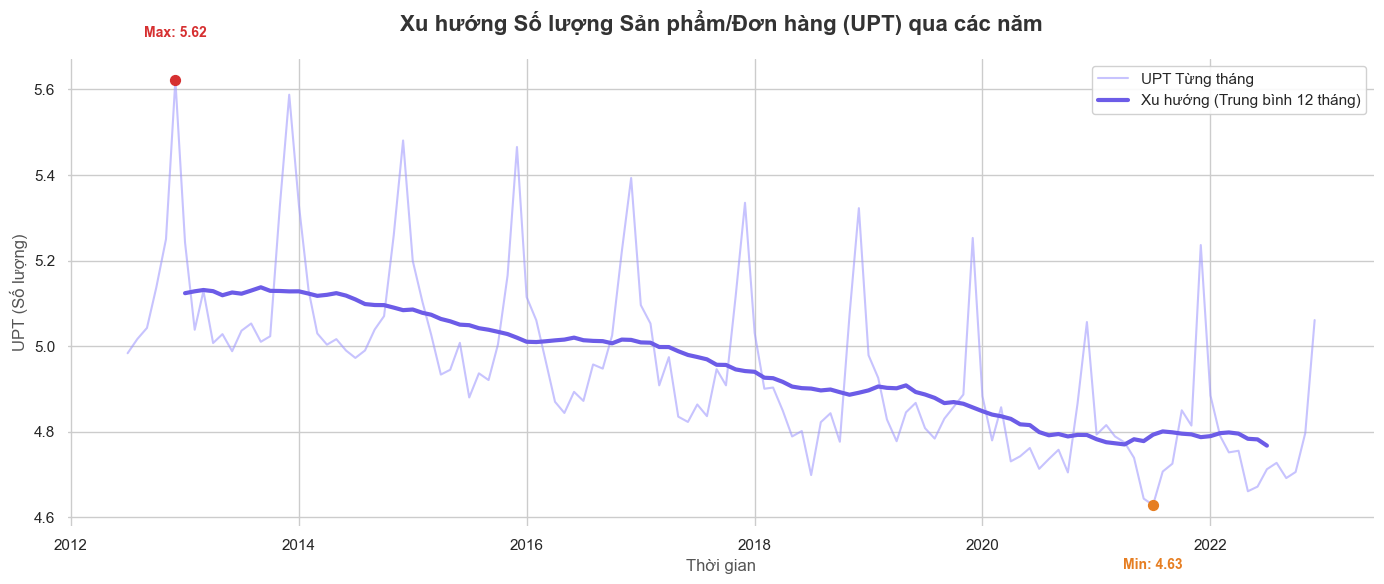

In [61]:
# 1. CHUẨN BỊ VÀ NỐI DỮ LIỆU
# Giả định bạn đã có df_orders chứa thời gian mua hàng
# df_order_items = pd.read_csv("order_items.csv")
# df_orders = pd.read_csv("orders.csv")

# Nối bảng order_items với orders để lấy cột order_date
df_merged = pd.merge(df_order_items, df_orders[['order_id', 'order_date']], on='order_id', how='inner')

# Ép kiểu thời gian và tạo cột Tháng
df_merged['order_date'] = pd.to_datetime(df_merged['order_date'])
df_merged['order_month'] = df_merged['order_date'].dt.to_period('M').dt.to_timestamp()

# 2. TÍNH TOÁN UPT THEO THÁNG
# Gom nhóm theo tháng: Tính tổng quantity và đếm số lượng order_id độc nhất
monthly_upt = df_merged.groupby('order_month').agg(
    total_quantity=('quantity', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Áp dụng công thức UPT
monthly_upt['UPT'] = monthly_upt['total_quantity'] / monthly_upt['total_orders']

# Chuyển định dạng tháng sang chuỗi (VD: '2023-01') để Bar Chart chia cột đều và đẹp hơn
monthly_upt['month_str'] = monthly_upt['order_month'].dt.strftime('%Y-%m')

# 3. VẼ BIỂU ĐỒ BAR CHART
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# 1. VẼ ĐƯỜNG UPT THEO THÁNG
sns.lineplot(
    data=monthly_upt, 
    x='order_month', 
    y='UPT', 
    color='#A29BFE', 
    linewidth=1.5,
    alpha=0.6,
    label='UPT Từng tháng'
)

# 2. VẼ ĐƯỜNG XU HƯỚNG (TRUNG BÌNH TRƯỢT 12 THÁNG)
monthly_upt['trend_12m'] = monthly_upt['UPT'].rolling(window=12, center=True).mean()

sns.lineplot(
    data=monthly_upt, 
    x='order_month', 
    y='trend_12m', 
    color='#6C5CE7', 
    linewidth=3,
    label='Xu hướng (Trung bình 12 tháng)'
)

# 3. TRANG TRÍ CHUẨN BÁO CÁO
plt.title('Xu hướng Số lượng Sản phẩm/Đơn hàng (UPT) qua các năm', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Thời gian', fontsize=12, color='#555555')
plt.ylabel('UPT (Số lượng)', fontsize=12, color='#555555')

sns.despine(bottom=True, left=True)

# 4. CHỈ GẮN NHÃN ĐIỂM MAX VÀ MIN
max_idx = monthly_upt['UPT'].idxmax()
min_idx = monthly_upt['UPT'].idxmin()

max_row = monthly_upt.loc[max_idx]
min_row = monthly_upt.loc[min_idx]

# Điểm cao nhất
plt.scatter(max_row['order_month'], max_row['UPT'], color='#D63031', s=50, zorder=5)
plt.text(max_row['order_month'], max_row['UPT'] + 0.1, f"Max: {max_row['UPT']:.2f}", 
         ha='center', fontsize=10, fontweight='bold', color='#D63031')

# Điểm thấp nhất
plt.scatter(min_row['order_month'], min_row['UPT'], color='#E67E22', s=50, zorder=5)
plt.text(min_row['order_month'], min_row['UPT'] - 0.15, f"Min: {min_row['UPT']:.2f}", 
         ha='center', fontsize=10, fontweight='bold', color='#E67E22')

# 5. ĐIỀU CHỈNH VỊ TRÍ CHÚ THÍCH (LEGEND) LÊN GÓC TRÊN BÊN PHẢI
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

### Gross margin by month

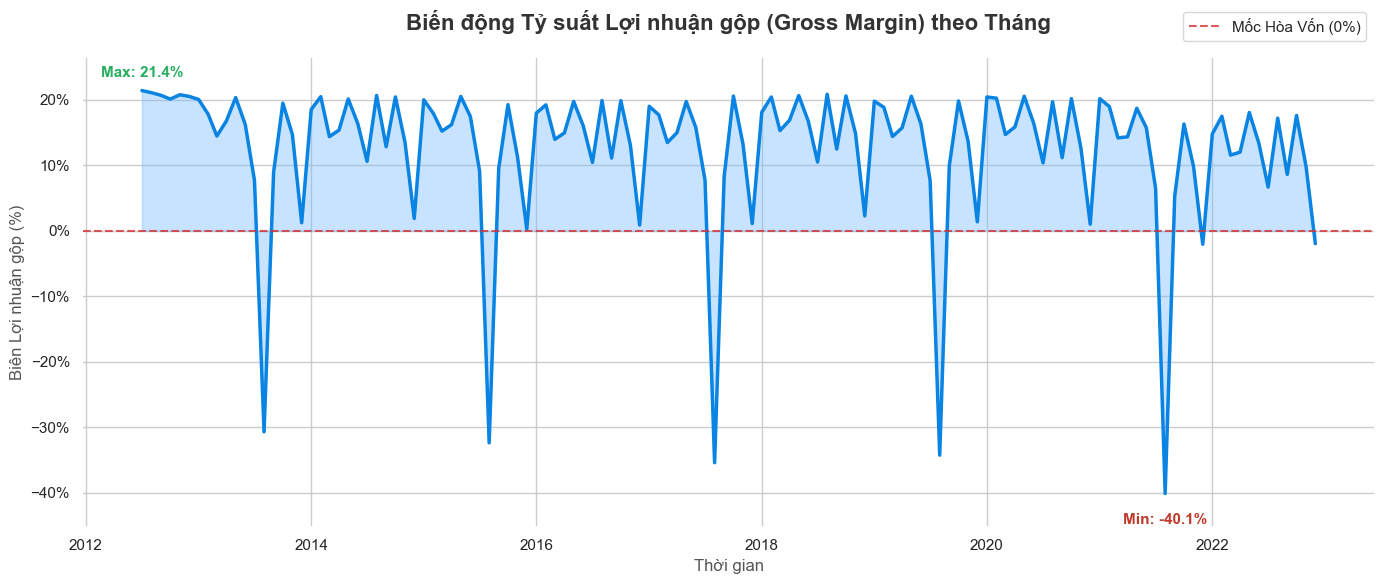

In [26]:
df_time = df_sales.set_index('Date').sort_index()

# TÍNH TOÁN GROSS MARGIN THEO THÁNG
# Bước 1: Tính tong Revenue và COGS theo từng tháng (MS = Month Start)
monthly_data = df_time[['Revenue', 'COGS']].resample('MS').sum().reset_index()
monthly_data['Gross_Margin'] = (monthly_data['Revenue'] - monthly_data['COGS']) / monthly_data['Revenue']

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Vẽ vùng diện tích
plt.fill_between(monthly_data['Date'], monthly_data['Gross_Margin'], color='#74B9FF', alpha=0.4)
plt.plot(monthly_data['Date'], monthly_data['Gross_Margin'], color='#0984E3', linewidth=2.5)

# ĐIỂM NHẤN MỚI: Thêm đường gạch ngang màu đỏ mờ ở mức 0% để phân định Ranh giới Lời/Lỗ
plt.axhline(0, color='#D63031', linestyle='--', linewidth=1.5, alpha=0.8, label='Mốc Hòa Vốn (0%)')

plt.title('Biến động Tỷ suất Lợi nhuận gộp (Gross Margin) theo Tháng', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Thời gian', fontsize=12, color='#555555')
plt.ylabel('Biên Lợi nhuận gộp (%)', fontsize=12, color='#555555')

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# THU GỌN TRỤC Y: Tự động co giãn dựa trên điểm Min/Max thực tế + thêm 1 chút khoảng không (buffer 5%)
y_min = monthly_data['Gross_Margin'].min()
y_max = monthly_data['Gross_Margin'].max()
plt.ylim(y_min - 0.05, y_max + 0.05) 

# Gắn nhãn
max_idx = monthly_data['Gross_Margin'].idxmax()
min_idx = monthly_data['Gross_Margin'].idxmin()
max_row = monthly_data.loc[max_idx]
min_row = monthly_data.loc[min_idx]

# Gắn nhãn Đỉnh (Max)
plt.text(max_row['Date'], max_row['Gross_Margin'] + 0.02, f"Max: {max_row['Gross_Margin']:.1%}", 
         ha='center', fontsize=11, fontweight='bold', color='#27AE60')

# Gắn nhãn Đáy (Min)
plt.text(min_row['Date'], min_row['Gross_Margin'] - 0.03, f"Min: {min_row['Gross_Margin']:.1%}", 
         ha='center', va='top', fontsize=11, fontweight='bold', color='#C0392B')

sns.despine(left=True, bottom=True)
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 1.02), frameon=True, facecolor='white')
plt.tight_layout()

plt.show()

In [ ]:
# 1. NỐI DỮ LIỆU
df_merged = pd.merge(df_order_items, df_products[['product_id', 'category']], on='product_id', how='left')
df_merged = pd.merge(df_merged, df_orders[['order_id', 'order_date']], on='order_id', how='left')

# 2. TÍNH DISCOUNT RATE
df_merged['order_date'] = pd.to_datetime(df_merged['order_date'])
df_merged['order_month'] = df_merged['order_date'].dt.to_period('M').dt.to_timestamp()

# Tính tỷ lệ giảm giá cho từng dòng sản phẩm
# Tránh chia cho 0 nếu quantity hoặc unit_price bằng 0
df_merged['discount_rate'] = df_merged['discount_amount'] / (df_merged['quantity'] * df_merged['unit_price'])
df_merged['discount_rate'] = df_merged['discount_rate'].fillna(0)

# 3. TỔNG HỢP THEO THÁNG VÀ CATEGORY
# Trung bình theo từng Category
cat_discount = df_merged.groupby(['order_month', 'category'])['discount_rate'].mean().reset_index()

# Trung bình chung toàn sàn (để làm đường so sánh "Dual")
overall_discount = df_merged.groupby('order_month')['discount_rate'].mean().reset_index()

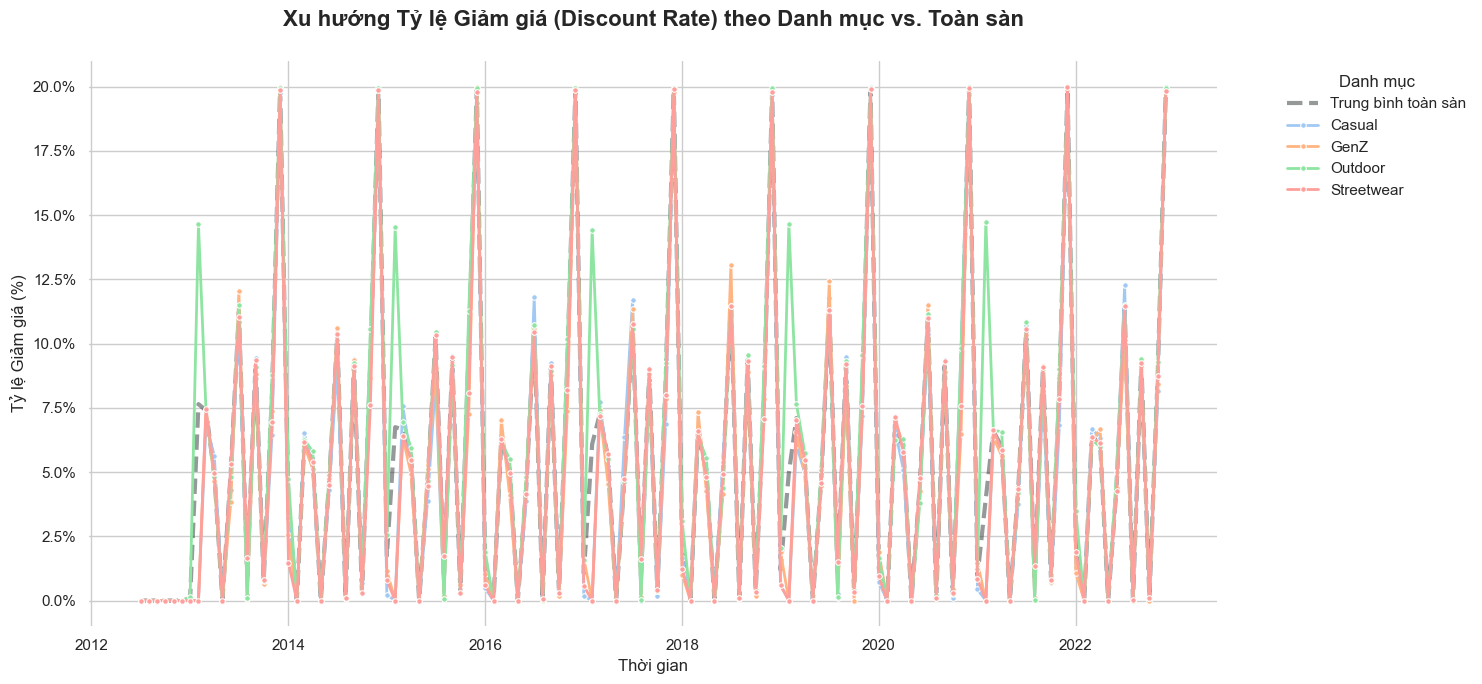

In [29]:
plt.figure(figsize=(15, 7))
sns.set_theme(style="whitegrid")

# Vẽ đường trung bình toàn sàn (Đường nền - Background line)
plt.plot(overall_discount['order_month'], overall_discount['discount_rate'], 
         color='#2D3436', linestyle='--', linewidth=3, alpha=0.5, label='Trung bình toàn sàn')

# Vẽ các đường theo từng Category (Sử dụng bảng màu Pastel)
ax = sns.lineplot(
    data=cat_discount, 
    x='order_month', 
    y='discount_rate', 
    hue='category', 
    palette='pastel', 
    linewidth=2,
    marker='o',
    markersize=4
)

# 4. TRANG TRÍ CHUẨN BÁO CÁO
plt.title('Xu hướng Tỷ lệ Giảm giá (Discount Rate) theo Danh mục vs. Toàn sàn', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Tỷ lệ Giảm giá (%)', fontsize=12)

# Định dạng trục Y sang %
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Tinh chỉnh Chú thích (Legend)
plt.legend(title='Danh mục', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

sns.despine(left=True, bottom=True)
plt.tight_layout()

# Gợi ý: Lưu file dạng PDF để chèn vào LaTeX cho sắc nét
# plt.savefig('discount_rate_analysis.pdf', format='pdf', bbox_inches='tight')

plt.show()

In [6]:
import pandas as pd
import numpy as np

# Giả định bạn đã đọc 4 bảng dữ liệu vào các DataFrame:
# df_web_traffic, df_orders, df_items, df_payments

# ==========================================
# BƯỚC 1: TỔNG HỢP SESSIONS TỪ WEB TRAFFIC
# ==========================================
df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
df_web_traffic['year'] = df_web_traffic['date'].dt.year

# Gom nhóm theo Năm và Nguồn truy cập
traffic_yearly = df_web_traffic.groupby(['year', 'traffic_source']).agg(
    total_sessions=('sessions', 'sum')
).reset_index()

# ==========================================
# BƯỚC 2: TỔNG HỢP ĐƠN HÀNG, DOANH THU & SẢN LƯỢNG
# ==========================================
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['year'] = df_orders['order_date'].dt.year

# Tính tổng số lượng sản phẩm (quantity) cho từng đơn hàng
items_agg = df_order_items.groupby('order_id').agg(
    total_units=('quantity', 'sum')
).reset_index()

# Gộp bảng Orders với Items và Payments
# Quan hệ orders và payments là 1:1, orders và items là 1:nhiều (nhưng ta đã gom nhóm items lại thành 1:1)
orders_merged = df_orders.merge(items_agg, on='order_id', how='left')
orders_merged = orders_merged.merge(df_payments[['order_id', 'payment_value']], on='order_id', how='left')

# Gom nhóm đơn hàng theo Năm và Nguồn tiếp thị (order_source)
orders_yearly = orders_merged.groupby(['year', 'order_source']).agg(
    total_orders=('order_id', 'count'),
    total_revenue=('payment_value', 'sum'),
    total_units=('total_units', 'sum')
).reset_index()

# ==========================================
# BƯỚC 3: MERGE FULL-FUNNEL VÀ TÍNH CHỈ SỐ
# ==========================================
# Nối bảng Traffic và bảng Orders
df_final = pd.merge(
    traffic_yearly,
    orders_yearly,
    left_on=['year', 'traffic_source'],
    right_on=['year', 'order_source'],
    how='outer' # Dùng outer để không bỏ sót nguồn nào
)

# Xử lý các giá trị NaN (ví dụ: có traffic nhưng không có đơn hàng)
df_final.fillna({'total_sessions': 0, 'total_orders': 0, 'total_revenue': 0, 'total_units': 0}, inplace=True)

# Đồng nhất tên cột nguồn (nếu có nguồn bị lệch giữa 2 bảng)
df_final['traffic_source'] = df_final['traffic_source'].combine_first(df_final['order_source'])

# TÍNH CÁC CHỈ SỐ PHÂN TÍCH (Lưu ý: dùng np.where để tránh lỗi chia cho 0)
df_final['conversion_rate'] = np.where(df_final['total_sessions'] > 0, 
                                       df_final['total_orders'] / df_final['total_sessions'], 0)

df_final['AOV'] = np.where(df_final['total_orders'] > 0, 
                           df_final['total_revenue'] / df_final['total_orders'], 0)

df_final['UPT'] = np.where(df_final['total_orders'] > 0, 
                           df_final['total_units'] / df_final['total_orders'], 0)

df_final['ASP'] = np.where(df_final['total_units'] > 0, 
                           df_final['total_revenue'] / df_final['total_units'], 0)

# ==========================================
# BƯỚC 4: LÀM SẠCH VÀ SẮP XẾP BẢNG KẾT QUẢ
# ==========================================
# Chọn lọc và đổi tên các cột theo đúng yêu cầu
dataset = df_final[[
    'year', 
    'traffic_source', 
    'total_sessions', 
    'conversion_rate', 
    'total_revenue', 
    'total_orders', 
    'AOV', 
    'UPT', 
    'ASP'
]].sort_values(by=['year', 'total_revenue'], ascending=[True, False]).reset_index(drop=True)

print(dataset.head())

dataset.to_csv('full_funnel_yearly.csv', index=False, encoding='utf-8')

   year  traffic_source  total_sessions  conversion_rate  total_revenue  \
0  2012  organic_search             0.0              0.0   2.078341e+08   
1  2012     paid_search             0.0              0.0   1.652197e+08   
2  2012    social_media             0.0              0.0   1.481767e+08   
3  2012  email_campaign             0.0              0.0   8.921455e+07   
4  2012        referral             0.0              0.0   7.284453e+07   

   total_orders           AOV       UPT          ASP  
0          9021  23038.920185  5.179470  4448.122999  
1          6984  23656.889764  5.224513  4528.056295  
2          6449  22976.693833  5.189487  4427.546494  
3          3879  22999.367822  5.183037  4437.430877  
4          3209  22700.070726  5.211592  4355.688051  
